# <span style='color:red'>NeuroSense - Stroke Prediction (Final Pipeline)</span>

End-to-end stroke prediction on the Kaggle Healthcare Stroke dataset.

**What this pipeline does:**
- Leak-free preprocessing: train/test split happens **before** imputation, scaling, encoding, and SMOTE
- Smart imputation: BMI predicted by gradient boosting; smoking "Unknown" predicted by Random Forest, with `smoking_was_unknown` retained as signal
- Imbalance handled three ways: `class_weight`, `scale_pos_weight`, and SMOTE-inside-CV (via `imblearn.Pipeline`)
- Optuna Bayesian hyperparameter optimization (40 trials each) on the strongest models, optimizing CV PR-AUC
- Probability calibration (isotonic) for clinically meaningful risk scores
- Decision-threshold tuning on training OOF predictions — test set untouched until final evaluation
- Stacking + soft-voting ensembles, evaluated on a clean held-out test set
- SHAP explainability for feature importance

## <span style='color:orange'>1. Importing all Packages</span>

In [1]:
# Core
import os, warnings, random, json
import joblib
import types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as ex
from scipy import stats

# Sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, cross_val_predict)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, PowerTransformer,
                                    LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Models (matches Islam et al. 2025 reference paper + extras)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, classification_report,
                              confusion_matrix, precision_recall_curve, roc_curve,
                              brier_score_loss, ConfusionMatrixDisplay)

# Tuning
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

# XAI
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('LightGBM available :', HAS_LGB)
print('Optuna available   :', HAS_OPTUNA)
print('SHAP available     :', HAS_SHAP)

LightGBM available : True
Optuna available   : False
SHAP available     : True


## <span style='color:orange'>2. Reading and Exploring the DataFrame</span>

Dataset: 5,110 patient records, 12 columns. Target = `stroke` (0/1). Source: Kaggle Healthcare Stroke Prediction Dataset.

In [2]:
from google.colab import drive, files
import shutil, os

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/NeuroSense'
DRIVE_CSV = f'{DRIVE_DIR}/healthcare-dataset-stroke-data.csv'
os.makedirs(DRIVE_DIR, exist_ok=True)

def is_valid_csv(path):
    try:
        with open(path, 'r', encoding='utf-8', errors='replace') as f:
            first = f.readline().strip().lstrip('﻿')
        return first.startswith('id,gender')
    except:
        return False

# Auto-delete if wrong file is saved in Drive
if os.path.exists(DRIVE_CSV) and not is_valid_csv(DRIVE_CSV):
    os.remove(DRIVE_CSV)
    print('Wrong file detected and removed from Drive. Please upload the correct CSV.')

if not os.path.exists(DRIVE_CSV):
    print('Upload healthcare-dataset-stroke-data.csv from your project folder...')
    uploaded = files.upload()
    fname = next(iter(uploaded))
    with open(DRIVE_CSV, 'wb') as f:
        f.write(uploaded[fname])
    if not is_valid_csv(DRIVE_CSV):
        os.remove(DRIVE_CSV)
        raise ValueError('Wrong file uploaded. Please upload healthcare-dataset-stroke-data.csv')
    print(f'Saved correctly to Drive: {DRIVE_CSV}')
else:
    print('Correct CSV found in Drive - loading directly.')

data = pd.read_csv(DRIVE_CSV, na_values=['N/A'])
print('Shape:', data.shape)
data.head()

Mounted at /content/drive
Correct CSV found in Drive - loading directly.
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# -- Colab: mount Drive for persistent CSV storage --
from google.colab import drive, files
import shutil, io

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/NeuroSense'
DRIVE_CSV = f'{DRIVE_DIR}/healthcare-dataset-stroke-data.csv'

os.makedirs(DRIVE_DIR, exist_ok=True)

if os.path.exists(DRIVE_CSV):
    print('Dataset found in Drive - loading directly.')
    csv_path = DRIVE_CSV
else:
    print('Dataset not in Drive. Please upload it now...')
    uploaded = files.upload()  # triggers file picker
    fname = next(iter(uploaded))
    # write raw bytes directly to Drive (avoids copy corruption)
    with open(DRIVE_CSV, 'wb') as f:
        f.write(uploaded[fname])
    csv_path = DRIVE_CSV
    print(f'Saved to Drive: {DRIVE_CSV}')

# Verify file looks like a real CSV before loading
with open(csv_path, 'r', encoding='utf-8', errors='replace') as f:
    preview = [next(f) for _ in range(3)]
print('File preview:')
for line in preview: print(line.strip())

data = pd.read_csv(csv_path, na_values=['N/A'], on_bad_lines='skip')
print('Shape:', data.shape)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found in Drive - loading directly.
File preview:
id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,N/A,never smoked,1
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
# Numerical summary
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
# Categorical summary
data.describe(include=object)

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [7]:
# Unique values in categorical columns
for col in data.select_dtypes(include=['object']).columns:
    print(f"Unique values in '{col}': {data[col].unique()}")

Unique values in 'gender': ['Male' 'Female' 'Other']
Unique values in 'ever_married': ['Yes' 'No']
Unique values in 'work_type': ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Unique values in 'Residence_type': ['Urban' 'Rural']
Unique values in 'smoking_status': ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


### <span style='color:gold'>Missing values</span>

In [8]:
print('Missing counts:')
print(data.isnull().sum())
print('\nMissing percentage:')
print((data.isnull().sum() / len(data) * 100).round(3))

Missing counts:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Missing percentage:
id                   0.000
gender               0.000
age                  0.000
hypertension         0.000
heart_disease        0.000
ever_married         0.000
work_type            0.000
Residence_type       0.000
avg_glucose_level    0.000
bmi                  3.933
smoking_status       0.000
stroke               0.000
dtype: float64


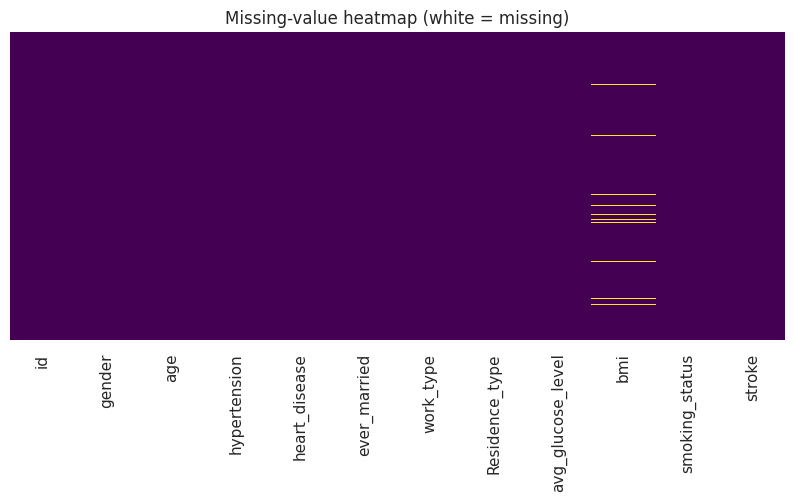

In [9]:
# Visualize missing pattern
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing-value heatmap (white = missing)')
plt.show()

### <span style='color:gold'>Data quality audit</span>

In [10]:
audit = pd.DataFrame({
    'dtype'      : data.dtypes.astype(str),
    'missing'    : data.isna().sum(),
    'missing_pct': (data.isna().mean() * 100).round(2),
    'unique'     : data.nunique(),
    'sample'     : [data[c].dropna().iloc[0] if data[c].notna().any() else None for c in data.columns]
})
audit

,dtype,missing,missing_pct,unique,sample
id,int64,0,0.00,5110,9046
gender,object,0,0.00,3,Male
age,float64,0,0.00,104,67.0
hypertension,int64,0,0.00,2,0
heart_disease,int64,0,0.00,2,1
ever_married,object,0,0.00,2,Yes
work_type,object,0,0.00,5,Private
Residence_type,object,0,0.00,2,Urban
avg_glucose_level,float64,0,0.00,3979,228.69
bmi,float64,201,3.93,418,36.6


## <span style='color:orange'>3. Initial Cleaning</span>

- Drop the singleton `gender='Other'` row
- Drop `id` (irrelevant)
- Normalise column casing: `Residence_type` -> `residence_type`
- Do NOT impute missing values yet - that happens after the train/test split.

In [11]:
CKPT = 'ckpt_01_cleaned.joblib'
if os.path.exists(CKPT):
    df = joblib.load(CKPT)
    print('[CKPT] Loaded cleaned df from', CKPT, df.shape)
else:
    df = data.rename(columns={'Residence_type': 'residence_type'}).copy()
    df = df[df['gender'] != 'Other'].copy()
    df = df.drop(columns=['id'])
    joblib.dump(df, CKPT)
    print('[CKPT] Saved cleaned df to', CKPT)
print('Shape after cleaning:', df.shape)
print('Genders:', df['gender'].unique())

[CKPT] Saved cleaned df to ckpt_01_cleaned.joblib
Shape after cleaning: (5109, 11)
Genders: ['Male' 'Female']


# <span style='color:red'>4. Target Distribution</span>

The class imbalance is the single most important fact about this dataset. Reproducing the visualizations from the paper (Fig 2) and the resources notebook (pie chart cell C38).

stroke
0    4860
1     249
Name: count, dtype: int64

Positive rate: 4.87 %
Imbalance ratio (neg : pos) = 19.5 : 1


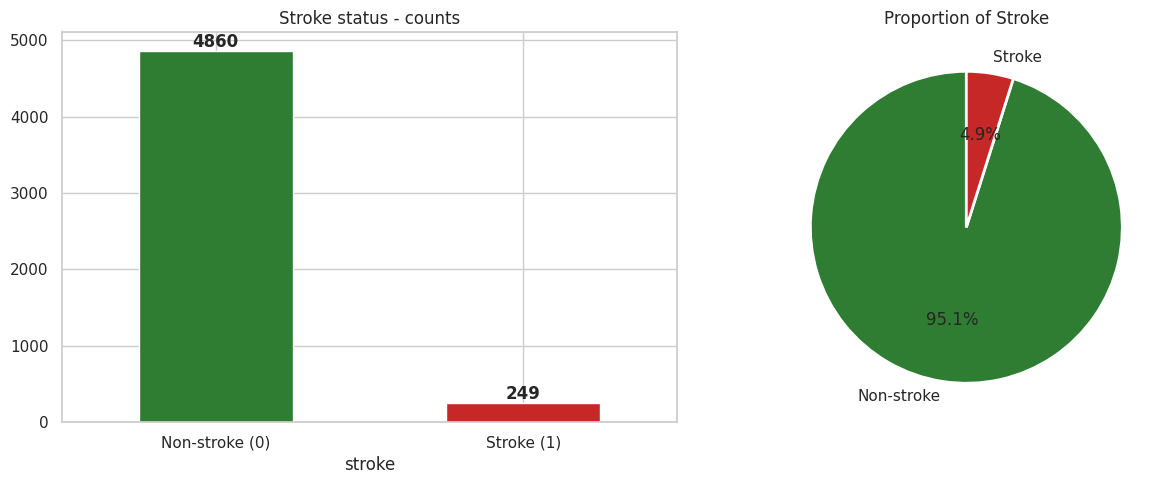

In [12]:
counts = df['stroke'].value_counts().sort_index()
print(counts)
print(f"\nPositive rate: {df['stroke'].mean()*100:.2f} %")
print(f"Imbalance ratio (neg : pos) = {counts[0] / counts[1]:.1f} : 1")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2e7d32', '#c62828']  # green / red - matches resources notebook
counts.plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Stroke status - counts')
ax[0].set_xticklabels(['Non-stroke (0)', 'Stroke (1)'], rotation=0)
for i, v in enumerate(counts.values):
    ax[0].text(i, v+50, str(v), ha='center', fontweight='bold')
ax[1].pie(counts, labels=['Non-stroke','Stroke'], colors=colors,
          autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax[1].set_title('Proportion of Stroke')
plt.tight_layout(); plt.show()

# <span style='color:red'>5. Exploratory Questions</span>

Same Q&A teaching style as the resources notebook - questions to anchor the EDA in clinical hypotheses we then verify with plots.

**Question 1.** Which age group has the highest stroke risk?

A. 0-20 | B. 20-40 | C. 40-60 | **D. 60+**

Stroke risk rises sharply after 60 - we will confirm this with the age-bin chart below.

**Question 2.** Which work type is most common among stroke patients?

**A. Private** | B. Self-employed | C. Govt. job | D. Never worked

Private-sector employment dominates the dataset overall, so it dominates stroke cases too. The relationship is correlation, not causation - the work_type "children" is essentially a redundant age signal.

**Question 3.** Most common smoking status among stroke patients?

A. Formerly smoked | **B. Never smoked** | C. Smokes | D. Unknown

Surprising at first, but consistent with literature - "never smoked" is the largest class in the data overall. The interesting signal is that *formerly smoked* has a higher stroke RATE than current smokers, likely a confounder with age (people quit when sick).

**Question 4.** Which factor is most strongly associated with stroke?

A. High BMI | **B. High average glucose level** | C. Living rural | D. Young age

After age, glucose level is the strongest single predictor. The KDE plots below show stroke cases concentrated above ~150 mg/dL.

# <span style='color:red'>6. Univariate Analysis</span>

One column at a time - distribution + relationship to the stroke target.

In [13]:
def cat_plot(col, df=df):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    df[col].value_counts().plot(kind='bar', ax=ax[0], color='#4c72b0')
    ax[0].set_title(f'{col} - counts'); ax[0].tick_params(axis='x', rotation=20)
    pd.crosstab(df[col], df['stroke'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax[1], color=['#2e7d32', '#c62828'])
    ax[1].set_title(f'Stroke proportion by {col}')
    ax[1].legend(['No stroke','Stroke']); ax[1].tick_params(axis='x', rotation=20)
    rate = df.groupby(col)['stroke'].mean().sort_values()
    rate.plot(kind='barh', ax=ax[2], color='#c62828')
    ax[2].set_title(f'Stroke rate by {col}')
    for i, v in enumerate(rate.values):
        ax[2].text(v+0.001, i, f'{v*100:.1f}%', va='center')
    plt.tight_layout(); plt.show()

def num_kde(col, df=df):
    """Color-coded KDE - matches resources notebook style (green/red)."""
    plt.figure(figsize=(11, 5))
    sns.kdeplot(data=df[df['stroke']==0], x=col, color='#2e7d32', fill=True,
                alpha=0.4, label='No Stroke')
    sns.kdeplot(data=df[df['stroke']==1], x=col, color='#c62828', fill=True,
                alpha=0.4, label='Stroke')
    plt.title(f'No Stroke vs Stroke - {col}'); plt.legend(); plt.show()

### <span style='color:gold'>Gender</span>

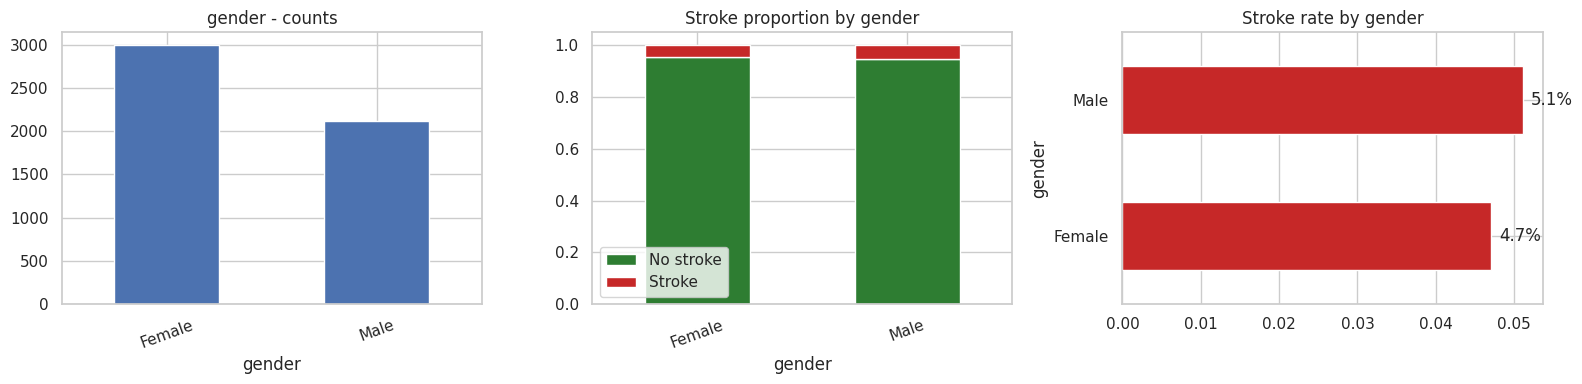

In [14]:
cat_plot('gender')

### <span style='color:gold'>Age</span>
Distribution + density by stroke (resources-notebook style).

Age stats:
count    5109.000000
mean       43.229986
std        22.613575
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

Under 18:  856
Under 2:   120  (likely encoded in fractional years)


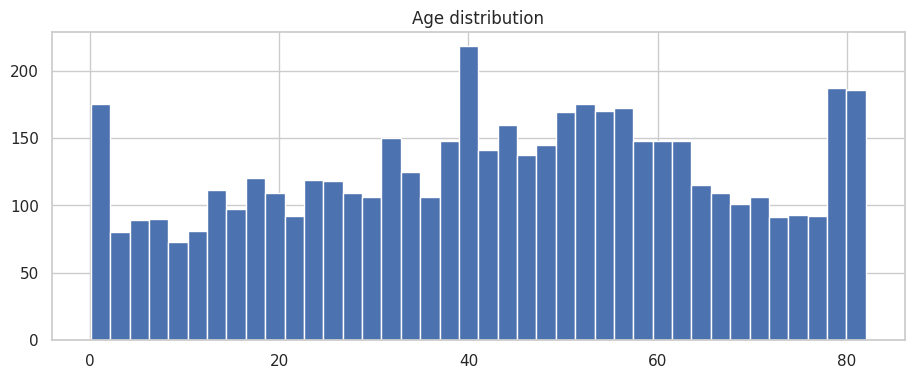

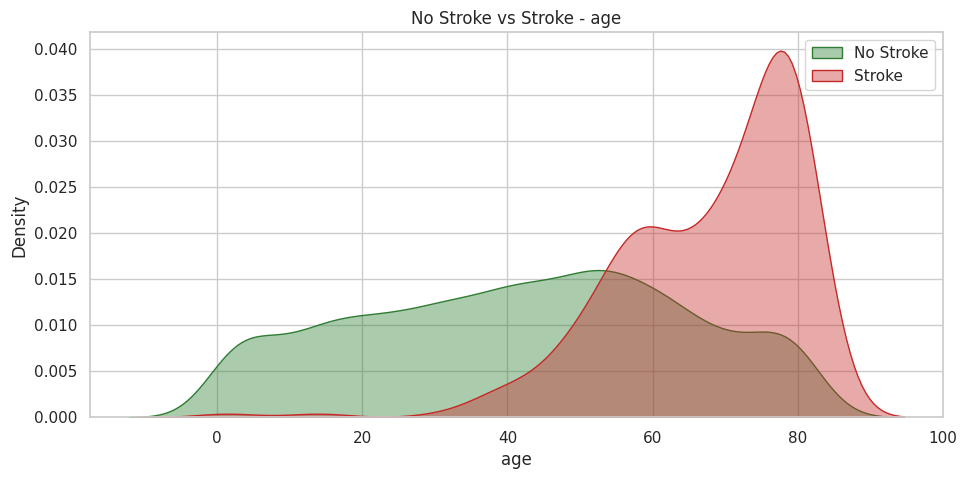

In [15]:
print('Age stats:'); print(df['age'].describe())
print(f"\nUnder 18:  {(df['age']<18).sum()}")
print(f"Under 2:   {(df['age']<2).sum()}  (likely encoded in fractional years)")
plt.figure(figsize=(11, 4))
df['age'].hist(bins=40, color='#4c72b0', edgecolor='white')
plt.title('Age distribution'); plt.show()
num_kde('age')

### <span style='color:gold'>Hypertension</span>

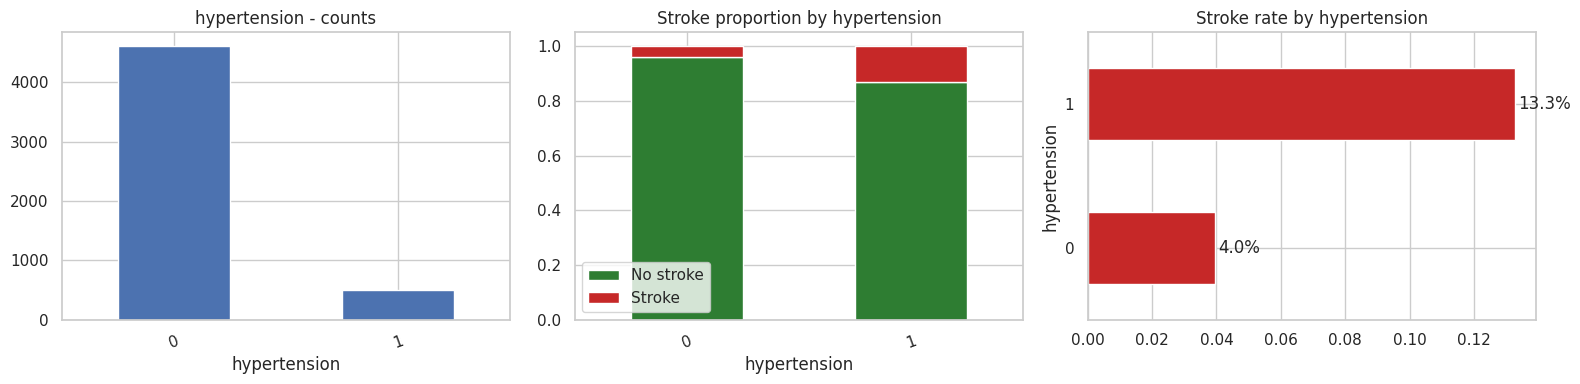

In [16]:
cat_plot('hypertension')

### <span style='color:gold'>Heart disease</span>

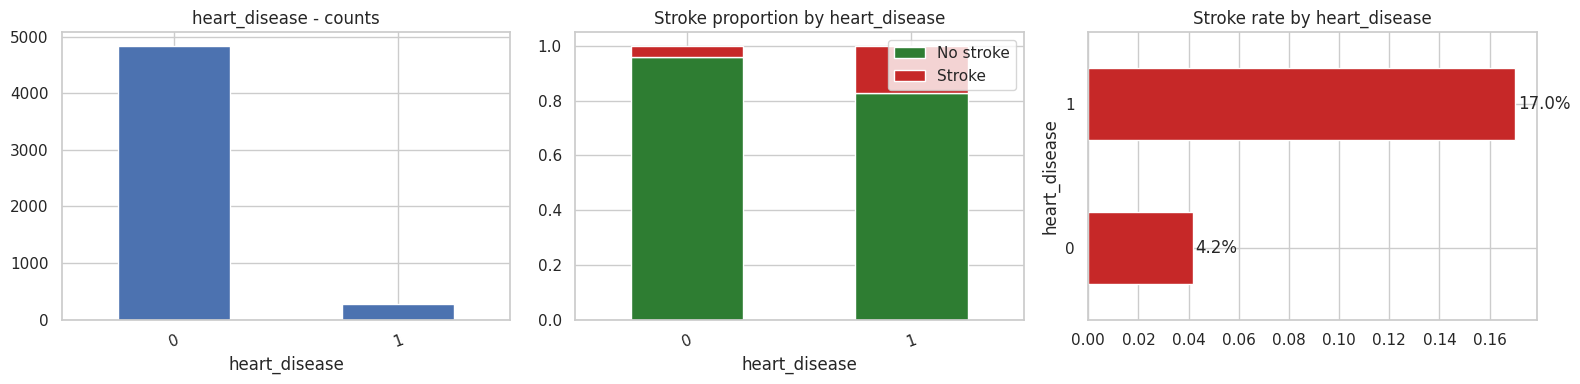

In [17]:
cat_plot('heart_disease')

### <span style='color:gold'>Ever married</span>

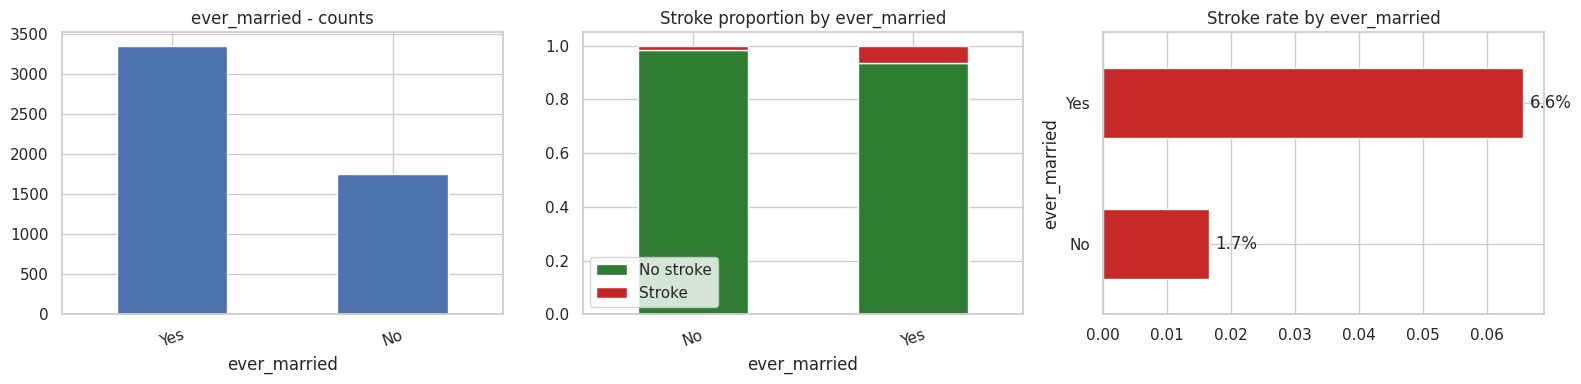

In [18]:
cat_plot('ever_married')

### <span style='color:gold'>Work type</span>

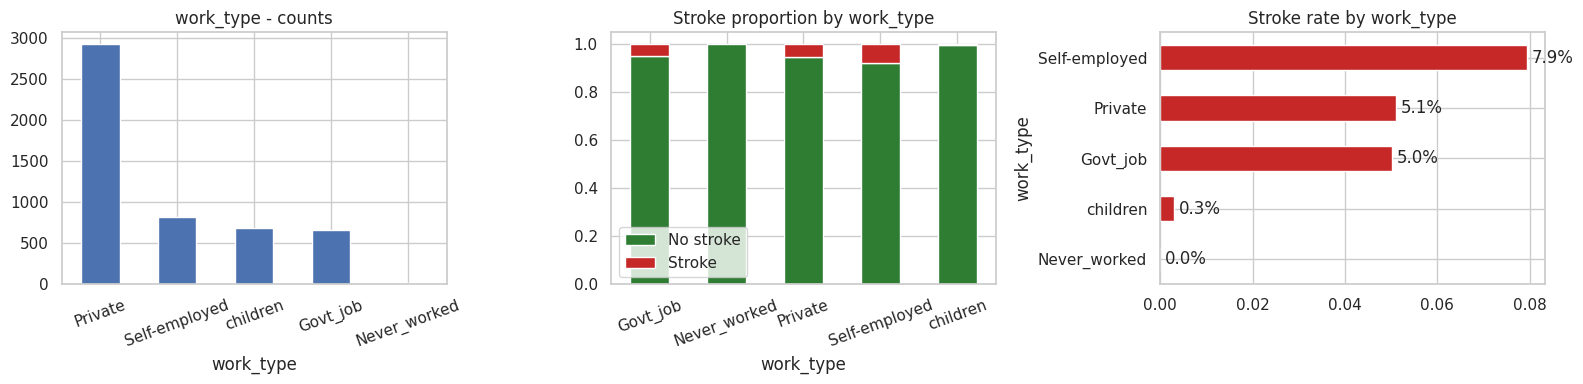

Median age by work_type:
work_type
children          6.0
Never_worked     16.0
Private          45.0
Govt_job         51.0
Self-employed    63.0
Name: age, dtype: float64


In [19]:
cat_plot('work_type')
print("Median age by work_type:")
print(df.groupby('work_type')['age'].median().sort_values())

### <span style='color:gold'>Residence type</span>

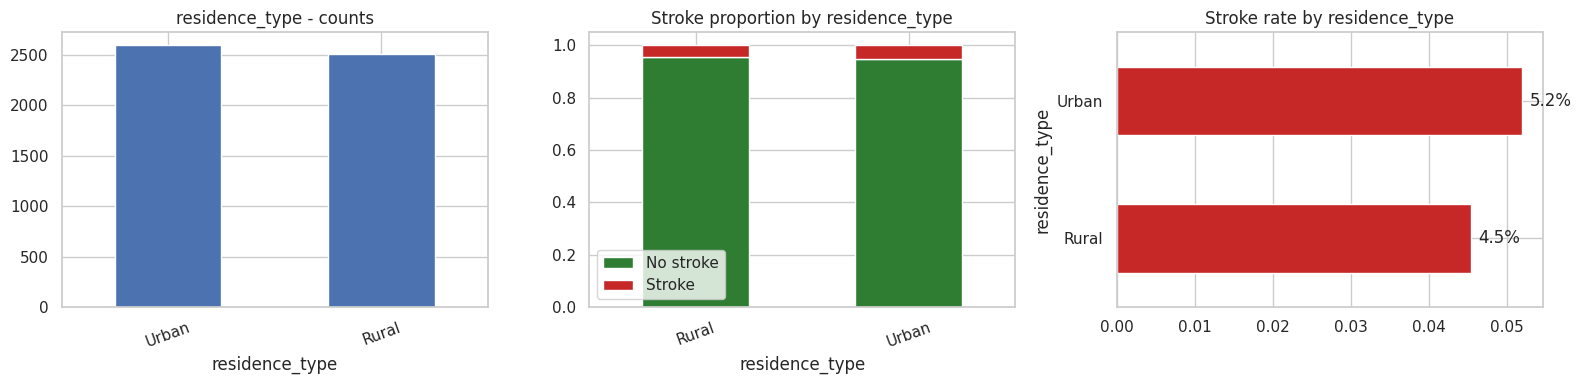

In [20]:
cat_plot('residence_type')

### <span style='color:gold'>Average glucose level</span>
Higher glucose levels concentrate in the stroke class - the red curve has heavy density above ~150 mg/dL.

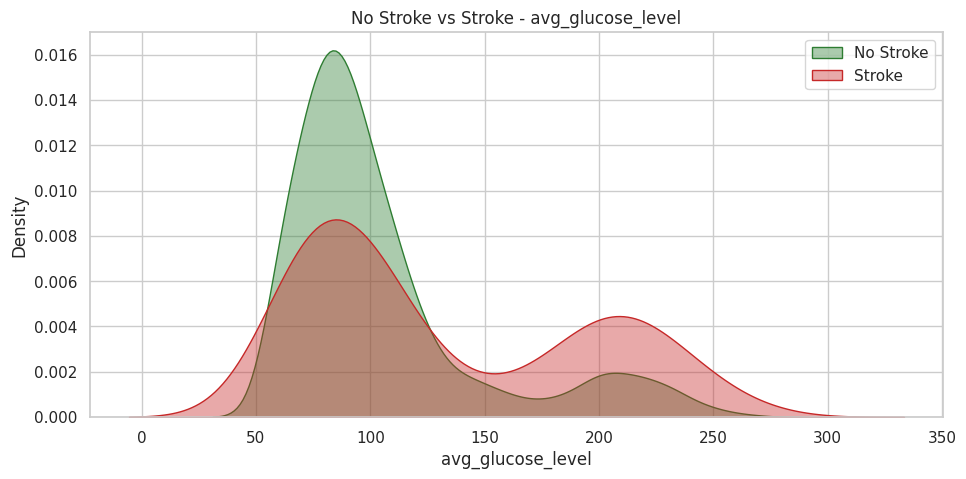

In [21]:
num_kde('avg_glucose_level')

### <span style='color:gold'>BMI</span>

bmi missing: 201 (3.93%)
Stroke rate where bmi missing : 19.90%
Stroke rate where bmi present : 4.26%


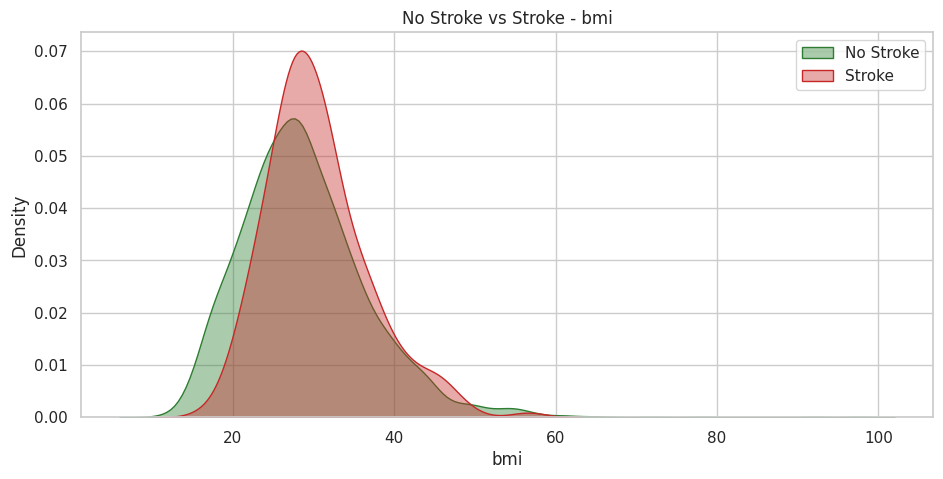

In [22]:
print(f"bmi missing: {df['bmi'].isna().sum()} ({df['bmi'].isna().mean()*100:.2f}%)")
print(f"Stroke rate where bmi missing : {df.loc[df['bmi'].isna(),'stroke'].mean()*100:.2f}%")
print(f"Stroke rate where bmi present : {df.loc[df['bmi'].notna(),'stroke'].mean()*100:.2f}%")
num_kde('bmi')

### <span style='color:gold'>Smoking status</span>
30% are "Unknown" - we model this as informative missingness AND predict the most likely class.

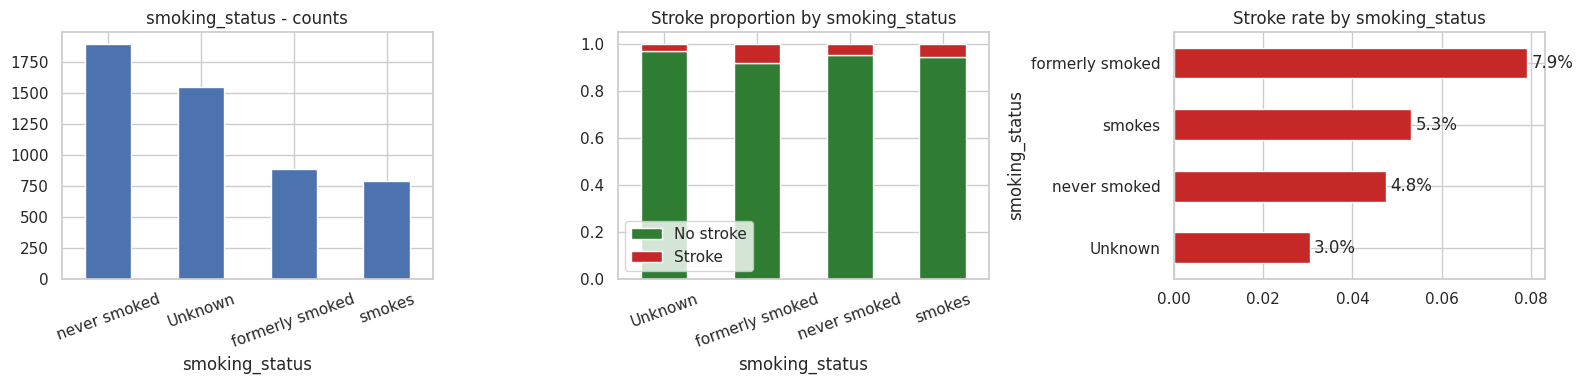

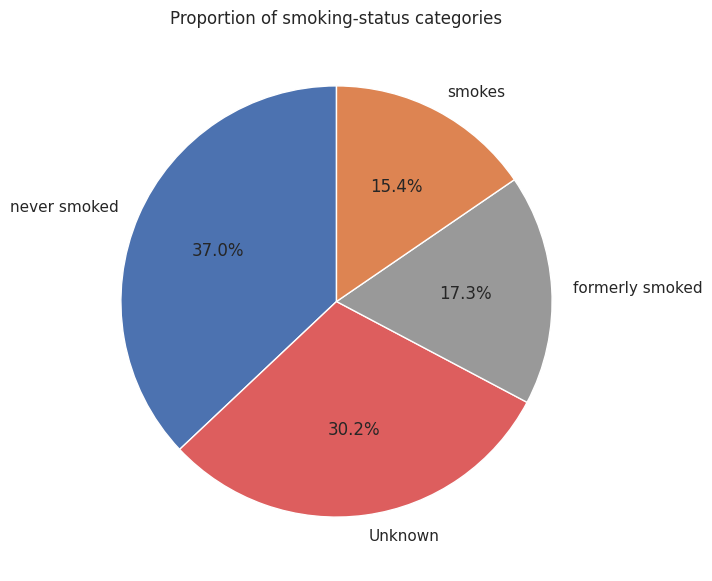

Proportion 'Unknown': 0.302


In [23]:
cat_plot('smoking_status')
# Pie chart from resources notebook
plt.figure(figsize=(7, 7))
df['smoking_status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,
    colors=['#4c72b0','#dd5e5e','#999999','#dd8452'])
plt.title('Proportion of smoking-status categories'); plt.ylabel(''); plt.show()
print("Proportion 'Unknown':", (df['smoking_status']=='Unknown').mean().round(3))

# <span style='color:red'>7. Bivariate and Multivariate Analysis</span>

### <span style='color:gold'>Smoking x Stroke (countplot)</span>

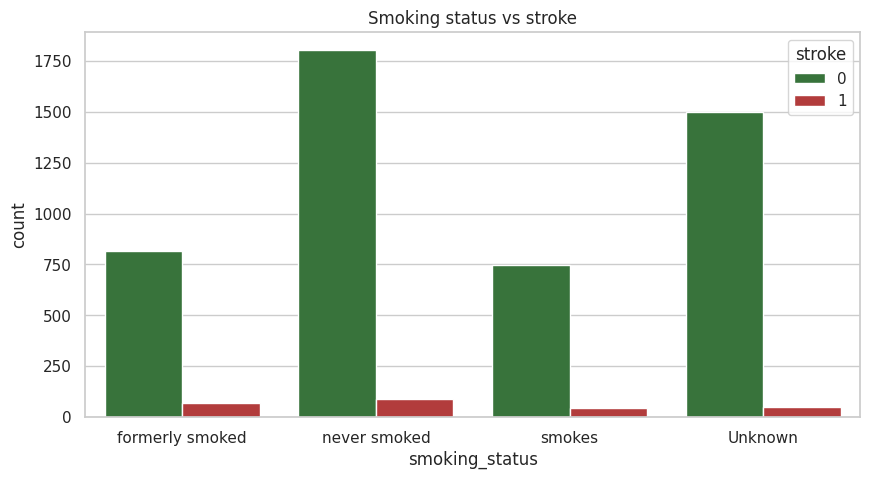

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='smoking_status', hue='stroke', palette=['#2e7d32','#c62828'])
plt.title('Smoking status vs stroke'); plt.show()

### <span style='color:gold'>Age x Glucose x BMI by stroke</span>

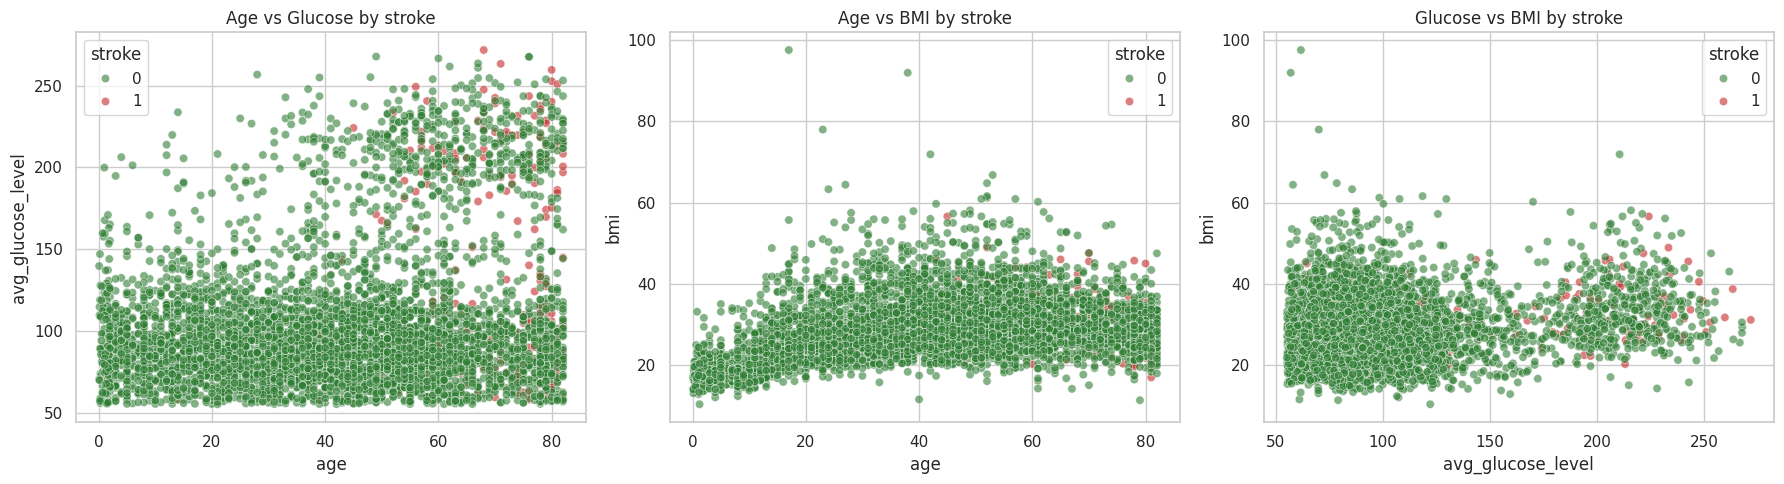

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke',
                palette=['#2e7d32','#c62828'], alpha=0.6, ax=ax[0])
ax[0].set_title('Age vs Glucose by stroke')
sns.scatterplot(data=df, x='age', y='bmi', hue='stroke',
                palette=['#2e7d32','#c62828'], alpha=0.6, ax=ax[1])
ax[1].set_title('Age vs BMI by stroke')
sns.scatterplot(data=df, x='avg_glucose_level', y='bmi', hue='stroke',
                palette=['#2e7d32','#c62828'], alpha=0.6, ax=ax[2])
ax[2].set_title('Glucose vs BMI by stroke')
plt.tight_layout(); plt.show()

### <span style='color:gold'>Stroke rate by age bin (the dominant signal)</span>

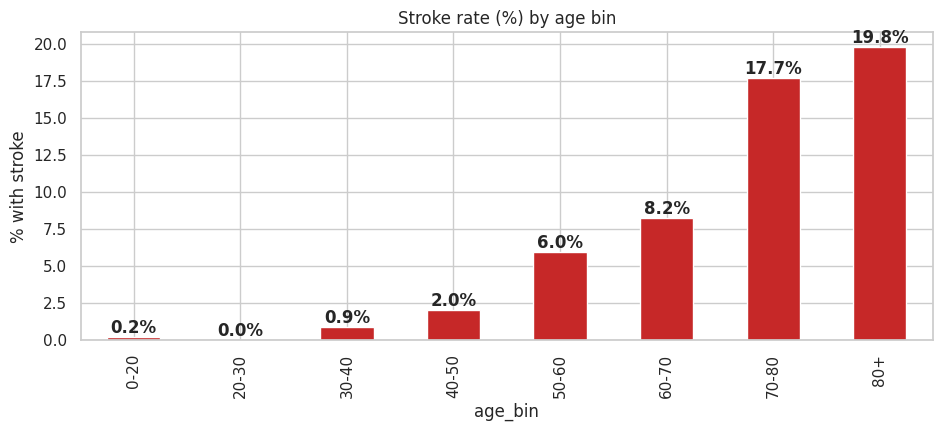

In [26]:
df['age_bin'] = pd.cut(df['age'], bins=[0,20,30,40,50,60,70,80,100],
                       labels=['0-20','20-30','30-40','40-50','50-60','60-70','70-80','80+'])
rate = df.groupby('age_bin')['stroke'].mean()*100
ax = rate.plot(kind='bar', figsize=(11,4), color='#c62828')
plt.title('Stroke rate (%) by age bin'); plt.ylabel('% with stroke')
for i,v in enumerate(rate.values):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()
df = df.drop(columns=['age_bin'])

### <span style='color:gold'>Numerical correlation heatmap</span>

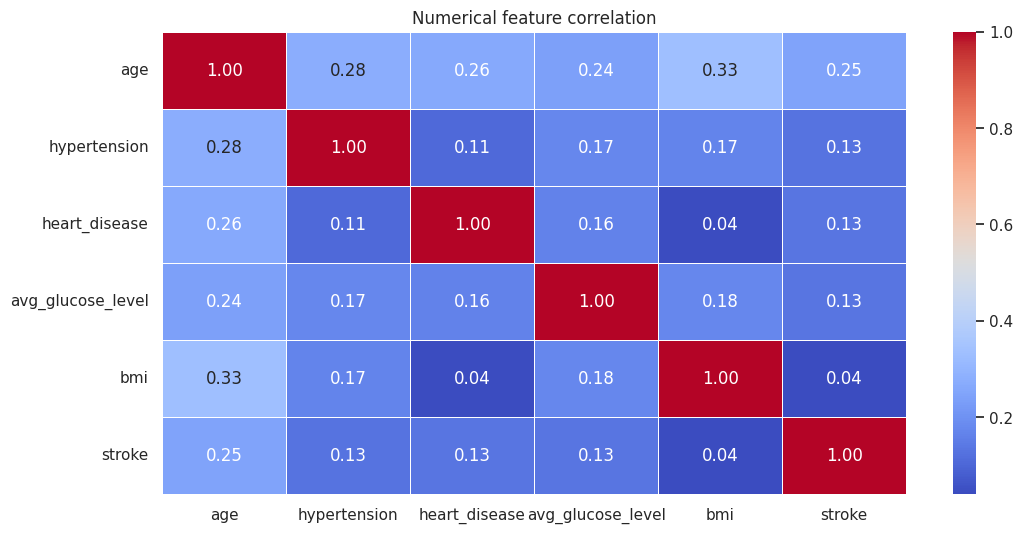

In [27]:
numerical_data = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 6))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numerical feature correlation'); plt.show()

### <span style='color:gold'>Full correlation matrix (encoded)</span>

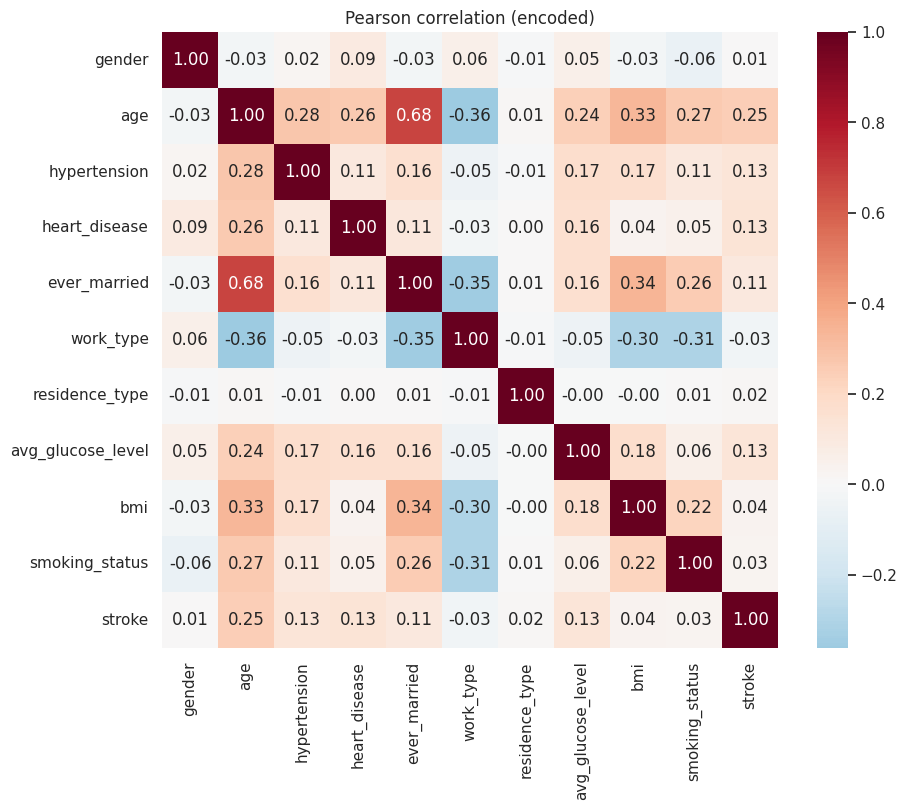

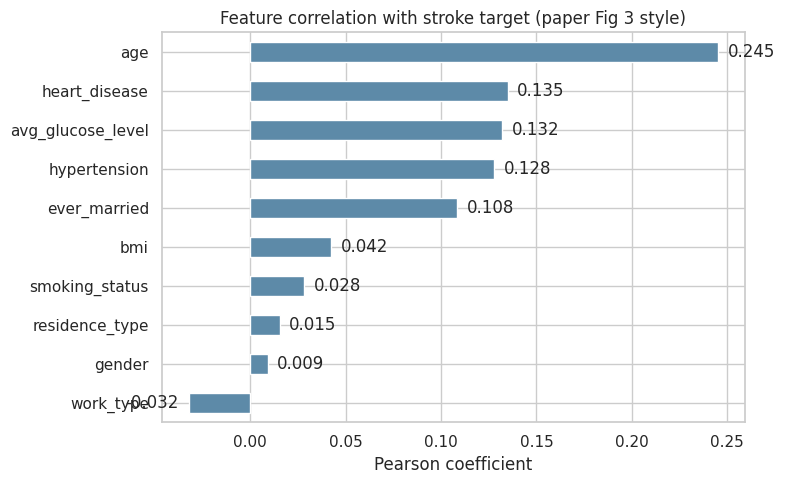

age                  0.245239
heart_disease        0.134905
avg_glucose_level    0.131991
hypertension         0.127891
ever_married         0.108299
bmi                  0.042341
smoking_status       0.028108
residence_type       0.015415
gender               0.009081
work_type           -0.032323
Name: stroke, dtype: float64


In [28]:
_corr_df = df.copy()
for c in _corr_df.select_dtypes(include='object').columns:
    _corr_df[c] = LabelEncoder().fit_transform(_corr_df[c].astype(str))
corr = _corr_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Pearson correlation (encoded)'); plt.show()

# Bar chart of correlation with stroke - matches paper Fig 3
target_corr = corr['stroke'].drop('stroke').sort_values(ascending=True)
plt.figure(figsize=(8, 5))
target_corr.plot(kind='barh', color='#5d8aa8')
plt.title('Feature correlation with stroke target (paper Fig 3 style)')
plt.xlabel('Pearson coefficient')
for i, v in enumerate(target_corr.values):
    plt.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
             va='center', ha='left' if v >= 0 else 'right')
plt.tight_layout(); plt.show()
print(target_corr.sort_values(ascending=False))

### <span style='color:gold'>Pair plot</span>

Quick visual check on every numeric pair - mirrors the resources notebook's `sns.pairplot(data)` cell.

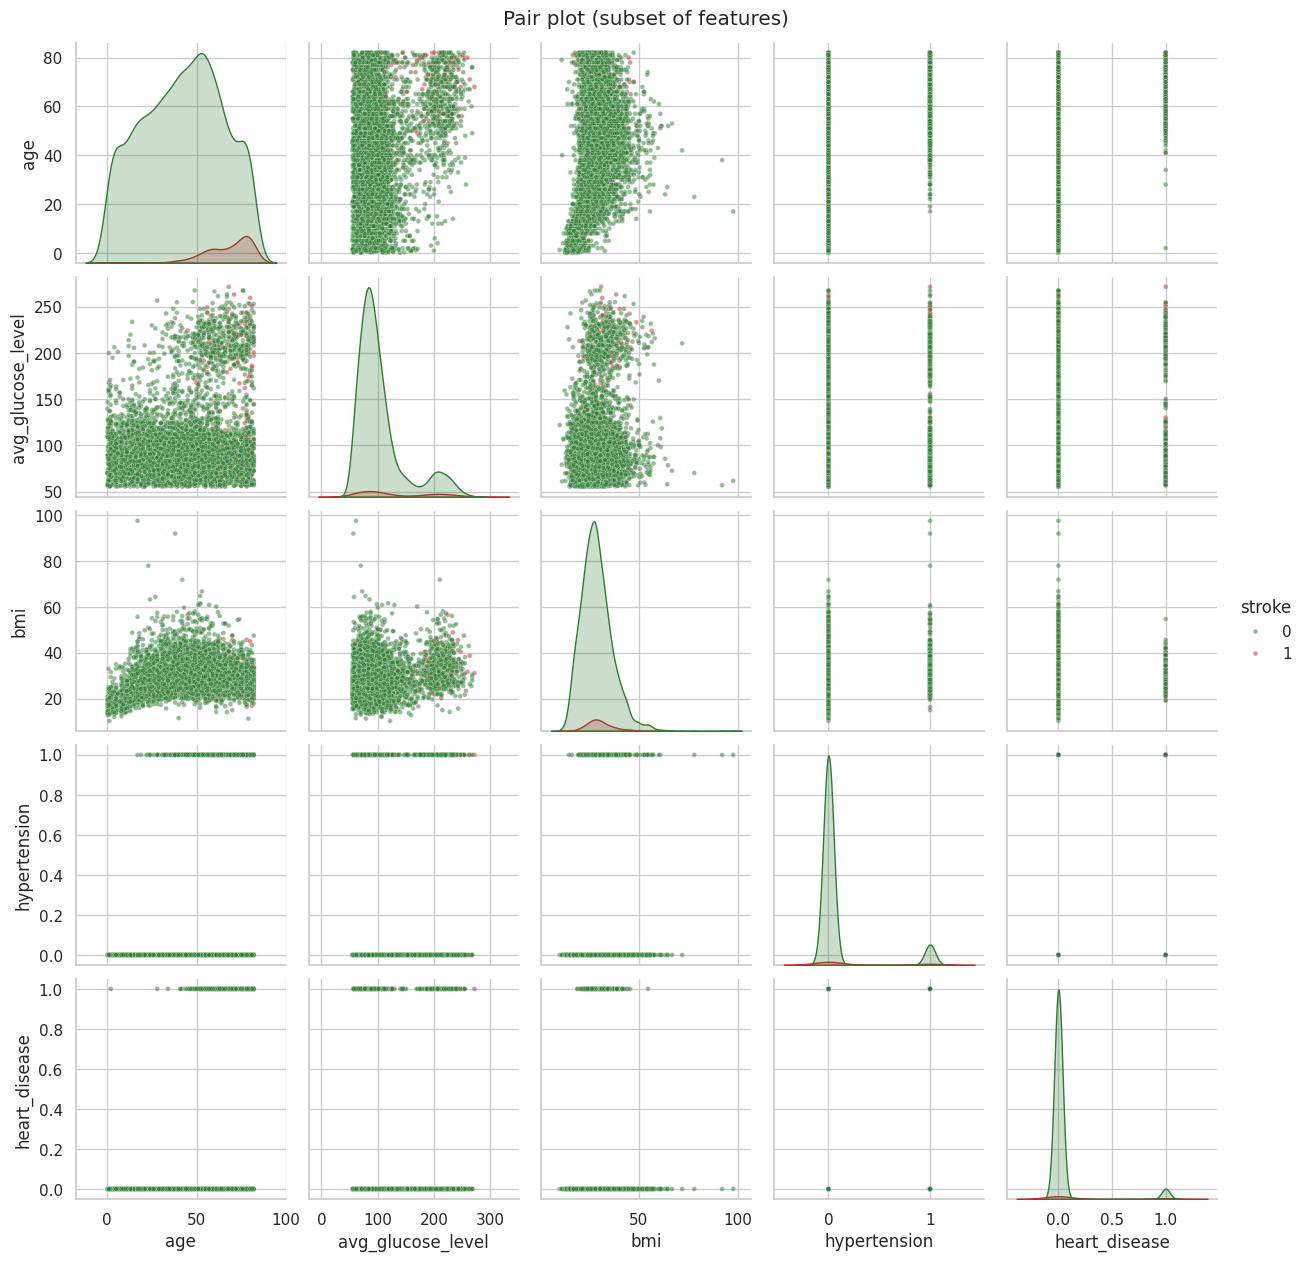

In [29]:
sns.pairplot(df[['age','avg_glucose_level','bmi','hypertension','heart_disease','stroke']],
             hue='stroke', palette=['#2e7d32','#c62828'], diag_kind='kde',
             plot_kws={'alpha':0.5, 's':12})
plt.suptitle('Pair plot (subset of features)', y=1.01); plt.show()

### <span style='color:gold'>Mutual information feature ranking</span>
Mutual information captures non-linear relationships that Pearson correlation misses.

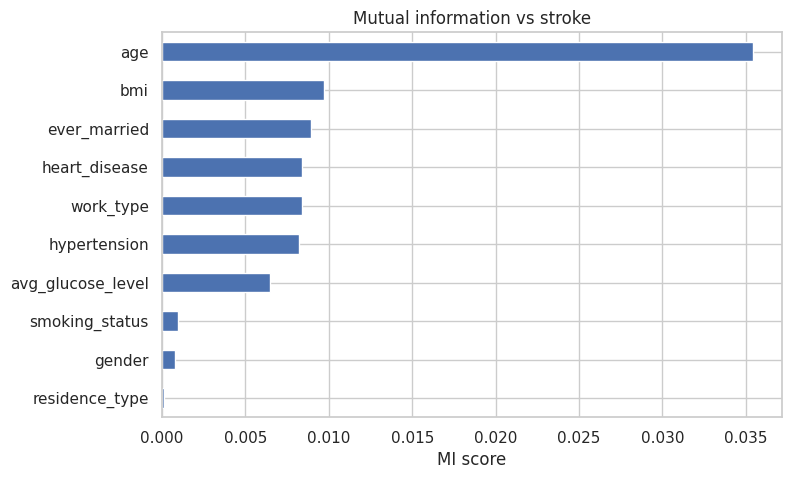

In [30]:
X_mi = _corr_df.drop(columns=['stroke']).fillna(_corr_df.median(numeric_only=True))
y_mi = _corr_df['stroke']
mi = mutual_info_classif(X_mi, y_mi, random_state=SEED)
mi_s = pd.Series(mi, index=X_mi.columns).sort_values(ascending=True)
mi_s.plot(kind='barh', figsize=(8,5), color='#4c72b0')
plt.title('Mutual information vs stroke'); plt.xlabel('MI score'); plt.show()

# <span style='color:red'>7b. Feature Interaction Analysis</span>

Looking at how pairs of features combine to drive stroke risk — these plots reveal interactions that univariate charts miss.

### <span style='color:gold'>Age × Glucose level combined risk surface</span>

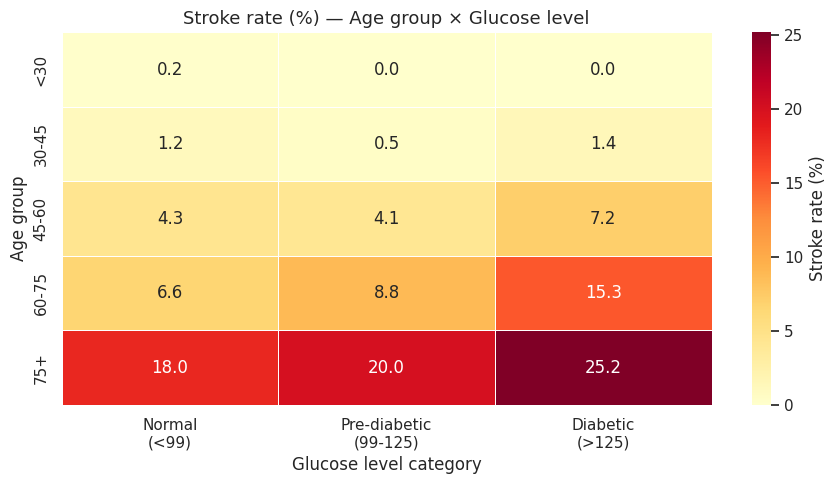

Each cell shows the % of patients in that age × glucose group who had a stroke.


In [31]:
# 2D heatmap: stroke rate (%) for every Age-group × Glucose-level combination
age_bins   = [0, 30, 45, 60, 75, 120]
age_labels = ['<30', '30-45', '45-60', '60-75', '75+']
glu_bins   = [0, 99, 125, 500]
glu_labels = ['Normal\n(<99)', 'Pre-diabetic\n(99-125)', 'Diabetic\n(>125)']

_heat = df.copy()
_heat['age_group'] = pd.cut(_heat['age'], bins=age_bins, labels=age_labels)
_heat['glu_group'] = pd.cut(_heat['avg_glucose_level'], bins=glu_bins, labels=glu_labels)
pivot = _heat.groupby(['age_group', 'glu_group'], observed=True)['stroke'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Stroke rate (%)'}, linewidths=0.5)
ax.set_title('Stroke rate (%) — Age group × Glucose level', fontsize=13)
ax.set_xlabel('Glucose level category')
ax.set_ylabel('Age group')
plt.tight_layout()
plt.show()
print("Each cell shows the % of patients in that age × glucose group who had a stroke.")


### <span style='color:gold'>BMI category × Hypertension × Stroke rate</span>

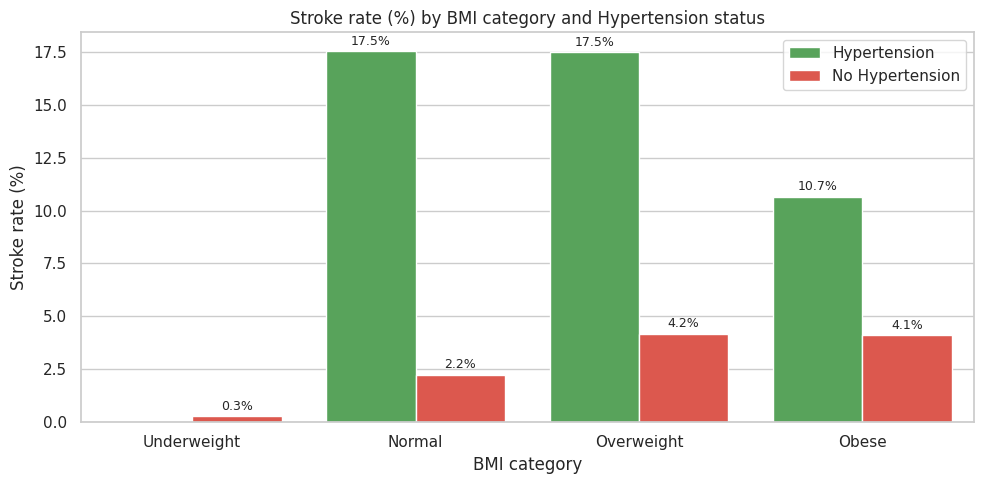

In [32]:
_bmi = df.copy()
_bmi['bmi_cat']   = pd.cut(_bmi['bmi'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
_bmi['hyp_label'] = _bmi['hypertension'].map({0: 'No Hypertension', 1: 'Hypertension'})
_grp = _bmi.groupby(['bmi_cat', 'hyp_label'], observed=True)['stroke'].mean().reset_index()
_grp['stroke_pct'] = _grp['stroke'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=_grp, x='bmi_cat', y='stroke_pct', hue='hyp_label',
            palette=['#4caf50', '#f44336'], ax=ax)
ax.set_title('Stroke rate (%) by BMI category and Hypertension status')
ax.set_xlabel('BMI category')
ax.set_ylabel('Stroke rate (%)')
ax.legend(title='')
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.15, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


# <span style='color:red'>8. Train / Test Split (BEFORE imputation or resampling)</span>

This is the critical engineering fix. Both `shoulder.ipynb` and the Islam et al. paper apply SMOTE before splitting (or split AFTER SMOTE), which leaks synthetic positives into the test set and inflates every metric.

Everything that uses fitted parameters from this point on is fit on `X_train` only and applied to `X_test`.

In [33]:
CKPT = 'ckpt_02_split.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    X_train, X_test, y_train, y_test = _d['X_train'], _d['X_test'], _d['y_train'], _d['y_test']
    print('[CKPT] Loaded split from', CKPT)
else:
    X = df.drop(columns=['stroke'])
    y = df['stroke']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED)
    joblib.dump({'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test}, CKPT)
    print('[CKPT] Saved split to', CKPT)
print('X_train:', X_train.shape, ' positives:', y_train.sum())
print('X_test :', X_test.shape,  ' positives:', y_test.sum())

[CKPT] Saved split to ckpt_02_split.joblib
X_train: (4087, 10)  positives: 199
X_test : (1022, 10)  positives: 50


## <span style='color:orange'>9. Smart Imputation (fit on train only)</span>

### <span style='color:gold'>Predict missing BMI with a regressor</span>

Reference paper and resources notebook both use mean imputation. We use a small gradient-boosting regressor that exploits other features (age, hypertension, heart_disease, glucose) - a stronger imputation that improves downstream model quality.

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

def impute_bmi(train, test):
    feat = ['age','hypertension','heart_disease','avg_glucose_level']
    train = train.copy(); test = test.copy()
    seen = train[train['bmi'].notna()]
    reg = GradientBoostingRegressor(random_state=SEED, n_estimators=200, max_depth=4)
    reg.fit(seen[feat], seen['bmi'])
    train.loc[train['bmi'].isna(), 'bmi'] = reg.predict(train.loc[train['bmi'].isna(), feat])
    test.loc[test['bmi'].isna(), 'bmi']   = reg.predict(test.loc[test['bmi'].isna(), feat])
    return train, test, reg

CKPT = 'ckpt_03_bmi.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    X_train, X_test, bmi_reg = _d['X_train'], _d['X_test'], _d['bmi_reg']
    print('[CKPT] Loaded BMI-imputed data from', CKPT)
else:
    X_train, X_test, bmi_reg = impute_bmi(X_train, X_test)
    joblib.dump({'X_train': X_train, 'X_test': X_test, 'bmi_reg': bmi_reg}, CKPT)
    print('[CKPT] Saved BMI-imputed data to', CKPT)
print('Train bmi missing after imputation:', X_train['bmi'].isna().sum())
print('Test  bmi missing after imputation:', X_test['bmi'].isna().sum())

[CKPT] Saved BMI-imputed data to ckpt_03_bmi.joblib
Train bmi missing after imputation: 0
Test  bmi missing after imputation: 0


### <span style='color:gold'>Predict "Unknown" smoking status</span>

We retain a `smoking_was_unknown` flag (the FACT of being unknown is signal - correlates with being a child) AND predict the most likely smoking status using a Random Forest trained on rows where smoking is known.

In [35]:
from sklearn.ensemble import RandomForestClassifier as RFC

def impute_smoking(train, test):
    train = train.copy(); test = test.copy()
    train['smoking_was_unknown'] = (train['smoking_status']=='Unknown').astype(int)
    test['smoking_was_unknown']  = (test['smoking_status']=='Unknown').astype(int)
    feat = ['age','hypertension','heart_disease','avg_glucose_level','bmi']
    known = train[train['smoking_status']!='Unknown']
    le = LabelEncoder().fit(known['smoking_status'])
    clf = RFC(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight='balanced')
    clf.fit(known[feat], le.transform(known['smoking_status']))
    for d in (train, test):
        mask = d['smoking_status']=='Unknown'
        if mask.any():
            d.loc[mask, 'smoking_status'] = le.inverse_transform(clf.predict(d.loc[mask, feat]))
    return train, test, clf, le

CKPT = 'ckpt_04_smoke.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    X_train, X_test, smoke_clf, smoke_le = _d['X_train'], _d['X_test'], _d['smoke_clf'], _d['smoke_le']
    print('[CKPT] Loaded smoking-imputed data from', CKPT)
else:
    X_train, X_test, smoke_clf, smoke_le = impute_smoking(X_train, X_test)
    joblib.dump({'X_train': X_train, 'X_test': X_test,
                 'smoke_clf': smoke_clf, 'smoke_le': smoke_le}, CKPT)
    print('[CKPT] Saved smoking-imputed data to', CKPT)
print('Train smoking values:', X_train['smoking_status'].unique())
print('Test  smoking values:', X_test['smoking_status'].unique())

[CKPT] Saved smoking-imputed data to ckpt_04_smoke.joblib
Train smoking values: ['never smoked' 'formerly smoked' 'smokes']
Test  smoking values: ['never smoked' 'formerly smoked' 'smokes']


# <span style='color:red'>10. Feature Engineering</span>

Domain-driven features that capture clinical stroke risk:
- Age bins (clinical risk groups)
- Glucose categories (normal / prediabetic / diabetic)
- BMI categories (under / normal / over / obese)
- `risk_score = hypertension + heart_disease` (cumulative comorbidity)
- Age x hypertension and Age x heart_disease interactions
- Glucose x age (compound metabolic-aging signal)

In [36]:
def add_features(d):
    d = d.copy()
    d['age_bin']     = pd.cut(d['age'], bins=[0,30,45,60,75,120],
                              labels=['young','adult','middle','senior','elderly']).astype(str)
    d['glucose_cat'] = pd.cut(d['avg_glucose_level'], bins=[0,99,125,500],
                              labels=['normal','prediabetic','diabetic']).astype(str)
    d['bmi_cat']     = pd.cut(d['bmi'], bins=[0,18.5,25,30,100],
                              labels=['under','normal','over','obese']).astype(str)
    d['risk_score']  = d['hypertension'] + d['heart_disease']
    d['age_x_hyp']   = d['age'] * d['hypertension']
    d['age_x_hd']    = d['age'] * d['heart_disease']
    d['glu_x_age']   = d['avg_glucose_level'] * d['age'] / 100
    return d

CKPT = 'ckpt_05_features.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    X_train, X_test = _d['X_train'], _d['X_test']
    print('[CKPT] Loaded feature-engineered data from', CKPT)
else:
    X_train = add_features(X_train)
    X_test  = add_features(X_test)
    joblib.dump({'X_train': X_train, 'X_test': X_test}, CKPT)
    print('[CKPT] Saved feature-engineered data to', CKPT)
X_train.head()

[CKPT] Saved feature-engineered data to ckpt_05_features.joblib


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,smoking_was_unknown,age_bin,glucose_cat,bmi_cat,risk_score,age_x_hyp,age_x_hd,glu_x_age
845,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,never smoked,0,middle,normal,obese,0,0.0,0.0,33.2208
3745,Female,29.0,0,0,No,Private,Urban,84.19,21.2,never smoked,0,young,normal,normal,0,0.0,0.0,24.4151
4184,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,never smoked,0,adult,prediabetic,normal,0,0.0,0.0,41.7900
3410,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,never smoked,0,adult,prediabetic,obese,0,0.0,0.0,41.2984
284,Male,14.0,0,0,No,Govt_job,Urban,82.34,31.6,never smoked,1,young,normal,obese,0,0.0,0.0,11.5276


## <span style='color:orange'>11. Preprocessing Pipeline (ColumnTransformer)</span>

All scaling and encoding lives inside the pipeline so it can be re-fit per CV fold without leakage. Numeric columns get a Yeo-Johnson power transform (handles skew without requiring positivity).

In [37]:
num_cols = ['age','avg_glucose_level','bmi','age_x_hyp','age_x_hd','glu_x_age']
bin_cols = ['hypertension','heart_disease','smoking_was_unknown','risk_score']
cat_cols = ['gender','ever_married','work_type','residence_type','smoking_status',
            'age_bin','glucose_cat','bmi_cat']

CKPT = 'ckpt_06_preproc.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    preproc, X_train_pp, X_test_pp, feat_names = (
        _d['preproc'], _d['X_train_pp'], _d['X_test_pp'], _d['feat_names'])
    print('[CKPT] Loaded preprocessor from', CKPT)
else:
    preproc = ColumnTransformer([
        ('num', Pipeline([('scale', PowerTransformer(method='yeo-johnson'))]), num_cols),
        ('bin', 'passthrough', bin_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    X_train_pp = preproc.fit_transform(X_train)
    X_test_pp  = preproc.transform(X_test)
    feat_names = (num_cols + bin_cols +
                  list(preproc.named_transformers_['cat'].get_feature_names_out(cat_cols)))
    joblib.dump({'preproc': preproc, 'X_train_pp': X_train_pp,
                 'X_test_pp': X_test_pp, 'feat_names': feat_names}, CKPT)
    print('[CKPT] Saved preprocessor to', CKPT)
print('Transformed shape:', X_train_pp.shape, '- total features:', len(feat_names))

[CKPT] Saved preprocessor to ckpt_06_preproc.joblib
Transformed shape: (4087, 36) - total features: 36


## <span style='color:orange'>12. Evaluation helper</span>

In [38]:
def evaluate(name, y_true, y_pred, y_proba=None, threshold=0.5):
    return {
        'model'   : name,
        'acc'     : accuracy_score(y_true, y_pred),
        'prec'    : precision_score(y_true, y_pred, zero_division=0),
        'recall'  : recall_score(y_true, y_pred, zero_division=0),
        'f1'      : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc' : roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        'pr_auc'  : average_precision_score(y_true, y_proba) if y_proba is not None else np.nan,
        'thresh'  : threshold,
    }

def tune_threshold(y_true, y_proba, target='f1'):
    """Pick threshold that maximises target metric on validation set."""
    p, r, t = precision_recall_curve(y_true, y_proba)
    if target == 'f1':
        f1_arr = 2*p*r / (p+r+1e-12)
        best = np.argmax(f1_arr[:-1])
        return t[best], f1_arr[best]
    if target == 'youden':
        fpr, tpr, t = roc_curve(y_true, y_proba)
        return t[np.argmax(tpr - fpr)], None
    raise ValueError(target)

# <span style='color:red'>13. Methodology Comparison — SMOTE-Inflated vs Leak-Free Evaluation</span>

This section compares two evaluation approaches using the same set of algorithms:

- **Naive approach**: SMOTE applied before the train/test split — synthetic samples leak into the test set and inflate every metric
- **Leak-free approach**: SMOTE applied only inside cross-validation on the training fold — test set contains only real patients

Both approaches use the same 8 algorithms: Random Forest, K-NN, MLP, AdaBoost, SVM, Decision Tree, XGBoost, and a Voting ensemble (RF + KNN + XGB).

We evaluate both on the same held-out real test set so the performance gap reflects evaluation methodology, not algorithm quality.

In [39]:
def paper_preprocess(train, test):
    base_cols = ['gender','age','hypertension','heart_disease','ever_married',
                 'work_type','residence_type','avg_glucose_level','bmi','smoking_status']
    train = train[base_cols].copy()
    test  = test[base_cols].copy()
    bmi_mean = train['bmi'].mean()
    train['bmi'] = train['bmi'].fillna(bmi_mean)
    test['bmi']  = test['bmi'].fillna(bmi_mean)
    for c in ['gender','ever_married','work_type','residence_type','smoking_status']:
        le = LabelEncoder().fit(train[c].astype(str))
        train[c] = le.transform(train[c].astype(str))
        test[c]  = le.transform(test[c].astype(str))
    return train, test

CKPT = 'ckpt_07_paper.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    paper_results = _d['paper_results']
    print('[CKPT] Loaded paper replication results from', CKPT)
    import pandas as _pd
    _pr_df = _pd.DataFrame(paper_results)
    print(_pr_df[['model','acc','f1','recall','prec','roc_auc','pr_auc']].round(3).to_string(index=False))
else:
    Xp_train, Xp_test = paper_preprocess(X_train, X_test)
    sm = SMOTE(random_state=SEED, k_neighbors=5)
    Xp_train_sm, yp_train_sm = sm.fit_resample(Xp_train, y_train)
    print('After SMOTE - train class counts:', pd.Series(yp_train_sm).value_counts().to_dict())
    paper_results = []
    paper_models = {
        'Random Forest'  : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
        'K-NN'           : KNeighborsClassifier(n_neighbors=5),
        'MLP'            : MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED),
        'AdaBoost'       : AdaBoostClassifier(n_estimators=100, random_state=SEED),
        'SVM'            : SVC(kernel='rbf', probability=True, random_state=SEED),
        'Decision Tree'  : DecisionTreeClassifier(random_state=SEED),
        'XGBoost'        : XGBClassifier(n_estimators=200, random_state=SEED,
                                         eval_metric='logloss', n_jobs=-1, verbosity=0),
    }
    scaler = StandardScaler().fit(Xp_train_sm)
    Xp_train_sm_s = scaler.transform(Xp_train_sm)
    Xp_test_s     = scaler.transform(Xp_test)
    print('\nPaper-replication results (honest test-set):\n')
    print(f'{"Algorithm":<18} {"Acc":>6} {"F1":>6} {"Recall":>7} {"Prec":>6} {"ROC":>6} {"PR-AUC":>7}')
    print('-'*60)
    for name, m in paper_models.items():
        needs_scale = name in ('K-NN','MLP','SVM')
        m.fit(Xp_train_sm_s if needs_scale else Xp_train_sm, yp_train_sm)
        Xt = Xp_test_s if needs_scale else Xp_test
        pred = m.predict(Xt)
        proba = m.predict_proba(Xt)[:,1] if hasattr(m, 'predict_proba') else None
        res = evaluate(name, y_test, pred, proba)
        paper_results.append(res)
        print(f'{name:<18} {res["acc"]:>6.3f} {res["f1"]:>6.3f} {res["recall"]:>7.3f} '
              f'{res["prec"]:>6.3f} {res["roc_auc"]:>6.3f} {res["pr_auc"]:>7.3f}')
    voting_paper = VotingClassifier(estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('xgb', XGBClassifier(n_estimators=200, random_state=SEED,
                              eval_metric='logloss', n_jobs=-1, verbosity=0)),
    ], voting='soft')
    voting_paper.fit(Xp_train_sm_s, yp_train_sm)
    pred = voting_paper.predict(Xp_test_s)
    proba = voting_paper.predict_proba(Xp_test_s)[:,1]
    res = evaluate('Voting (RF+KNN+XGB)', y_test, pred, proba)
    paper_results.append(res)
    print(f'{"Voting (paper)":<18} {res["acc"]:>6.3f} {res["f1"]:>6.3f} {res["recall"]:>7.3f} '
          f'{res["prec"]:>6.3f} {res["roc_auc"]:>6.3f} {res["pr_auc"]:>7.3f}')
    joblib.dump({'paper_results': paper_results}, CKPT)
    print('[CKPT] Saved paper replication results to', CKPT)

After SMOTE - train class counts: {0: 3888, 1: 3888}

Paper-replication results (honest test-set):

Algorithm             Acc     F1  Recall   Prec    ROC  PR-AUC
------------------------------------------------------------
Random Forest       0.897  0.198   0.260  0.160  0.757   0.117
K-NN                0.784  0.140   0.360  0.087  0.660   0.088
MLP                 0.851  0.200   0.380  0.136  0.766   0.169
AdaBoost            0.757  0.200   0.620  0.119  0.784   0.164
SVM                 0.782  0.165   0.440  0.101  0.747   0.131
Decision Tree       0.861  0.155   0.260  0.110  0.576   0.065
XGBoost             0.896  0.145   0.180  0.122  0.753   0.108
Voting (paper)      0.892  0.203   0.280  0.159  0.741   0.109
[CKPT] Saved paper replication results to ckpt_07_paper.joblib


### <span style='color:gold'>Comparison: paper-claimed vs our honest evaluation</span>

In [40]:
paper_claimed = {
    'Random Forest'      : (0.93, 0.92, 0.94, 0.90),
    'K-NN'               : (0.90, 0.91, 0.90, 0.91),
    'MLP'                : (0.89, 0.90, 0.88, 0.91),
    'AdaBoost'           : (0.92, 0.92, 0.93, 0.91),
    'SVM'                : (0.93, 0.92, 0.92, 0.91),
    'Decision Tree'      : (0.90, 0.91, 0.90, 0.91),
    'XGBoost'            : (0.94, 0.92, 0.87, 0.90),
    'Voting (RF+KNN+XGB)': (0.95, 0.93, 0.95, 0.92),
}
rows = []
for r in paper_results:
    cl = paper_claimed.get(r['model'], (np.nan,)*4)
    rows.append({
        'model': r['model'],
        'paper_acc': cl[0], 'our_acc': r['acc'],
        'paper_f1': cl[1],  'our_f1': r['f1'],
        'paper_recall': cl[2], 'our_recall': r['recall'],
        'paper_prec': cl[3], 'our_prec': r['prec'],
    })
cmp_df = pd.DataFrame(rows).round(3)
cmp_df

,model,paper_acc,our_acc,paper_f1,our_f1,paper_recall,our_recall,paper_prec,our_prec
0,Random Forest,0.93,0.897,0.92,0.198,0.94,0.26,0.90,0.160
1,K-NN,0.90,0.784,0.91,0.140,0.90,0.36,0.91,0.087
2,MLP,0.89,0.851,0.90,0.200,0.88,0.38,0.91,0.136
3,AdaBoost,0.92,0.757,0.92,0.200,0.93,0.62,0.91,0.119
4,SVM,0.93,0.782,0.92,0.165,0.92,0.44,0.91,0.101
5,Decision Tree,0.90,0.861,0.91,0.155,0.90,0.26,0.91,0.110
6,XGBoost,0.94,0.896,0.92,0.145,0.87,0.18,0.90,0.122
7,Voting (RF+KNN+XGB),0.95,0.892,0.93,0.203,0.95,0.28,0.92,0.159


# <span style='color:red'>14. Leak-Free Model Development (the proper pipeline)</span>

Now we use the full feature-engineered dataset and an `ImbPipeline` so SMOTE (when used) is fit INSIDE each CV fold, not on the whole training set. Metrics here will hold up when the model meets new patients.

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
trained_models = {}
spw = (y_train==0).sum() / (y_train==1).sum()

def fit_and_eval(name, estimator, use_smote=False, calibrate=False, tune_thr=True):
    _ckpt = f'ckpt_model_{name.replace(" ","_").replace("-","_")}.joblib'
    if os.path.exists(_ckpt):
        _d = joblib.load(_ckpt)
        if not any(r['model'] == name for r in results):
            results.append(_d['metrics'])
        trained_models[name] = _d['pipeline']
        m = _d['metrics']
        print(f"[CKPT] {name:<22} cv_pr={m['cv_pr_auc']:.3f} cv_roc={m['cv_roc_auc']:.3f}  "
              f"test_pr={m['pr_auc']:.3f} test_roc={m['roc_auc']:.3f}  "
              f"f1={m['f1']:.3f} prec={m['prec']:.3f} recall={m['recall']:.3f} (thr={m['thresh']:.2f})")
        return _d['pipeline']

    steps = [('preproc', preproc)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=SEED, k_neighbors=5)))
    steps.append(('model', estimator))
    pipe = ImbPipeline(steps)

    cv_pr  = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='average_precision', n_jobs=-1)
    cv_roc = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    pipe.fit(X_train, y_train)
    if calibrate:
        pipe = CalibratedClassifierCV(pipe, method='isotonic', cv=5)
        pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:,1]
    thr = 0.5
    if tune_thr:
        oof = cross_val_predict(
            ImbPipeline([('preproc', preproc),
                         ('model', estimator.__class__(**estimator.get_params()))]),
            X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
        thr, _ = tune_threshold(y_train, oof, target='f1')
    pred = (proba >= thr).astype(int)

    m = evaluate(name, y_test, pred, proba, thr)
    m['cv_pr_auc']  = cv_pr.mean()
    m['cv_roc_auc'] = cv_roc.mean()
    results.append(m)
    trained_models[name] = pipe

    joblib.dump({'metrics': m, 'pipeline': pipe}, _ckpt)
    print(f"{name:<22} cv_pr={m['cv_pr_auc']:.3f} cv_roc={m['cv_roc_auc']:.3f}  "
          f"test_pr={m['pr_auc']:.3f} test_roc={m['roc_auc']:.3f}  "
          f"f1={m['f1']:.3f} prec={m['prec']:.3f} recall={m['recall']:.3f} (thr={thr:.2f})")
    return pipe

### <span style='color:orange'>Logistic Regression</span>

In [42]:
fit_and_eval('LogReg', LogisticRegression(max_iter=2000, class_weight='balanced',
                                          random_state=SEED, n_jobs=-1))

LogReg                 cv_pr=0.184 cv_roc=0.836  test_pr=0.249 test_roc=0.835  f1=0.309 prec=0.244 recall=0.420 (thr=0.80)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, random_state=42))])

### <span style='color:orange'>Random Forest</span>

In [43]:
fit_and_eval('RandomForest', RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                                    random_state=SEED, n_jobs=-1))

RandomForest           cv_pr=0.125 cv_roc=0.793  test_pr=0.154 test_roc=0.776  f1=0.228 prec=0.136 recall=0.700 (thr=0.07)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

### <span style='color:orange'>SVM (RBF)</span>

In [44]:
fit_and_eval('SVM-RBF', SVC(kernel='rbf', class_weight='balanced',
                            probability=True, random_state=SEED))

SVM-RBF                cv_pr=0.143 cv_roc=0.777  test_pr=0.139 test_roc=0.767  f1=0.202 prec=0.131 recall=0.440 (thr=0.11)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

### <span style='color:orange'>XGBoost</span>

In [45]:
spw = (y_train==0).sum() / (y_train==1).sum()
fit_and_eval('XGBoost', XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1, verbosity=0))

XGBoost                cv_pr=0.127 cv_roc=0.792  test_pr=0.145 test_roc=0.791  f1=0.216 prec=0.129 recall=0.660 (thr=0.26)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### <span style='color:orange'>LightGBM</span>

In [46]:
if HAS_LGB:
    fit_and_eval('LightGBM', LGBMClassifier(
        n_estimators=400, num_leaves=31, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, is_unbalance=True,
        random_state=SEED, n_jobs=-1, verbose=-1))
else:
    print('LightGBM not installed - skipping. pip install lightgbm to enable.')

LightGBM               cv_pr=0.121 cv_roc=0.788  test_pr=0.146 test_roc=0.787  f1=0.189 prec=0.109 recall=0.700 (thr=0.01)


### <span style='color:orange'>K-Nearest Neighbors</span>

In [47]:
fit_and_eval('KNN', KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
             use_smote=True)

KNN                    cv_pr=0.103 cv_roc=0.751  test_pr=0.119 test_roc=0.751  f1=0.172 prec=0.096 recall=0.820 (thr=0.12)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 KNeighborsClassifier(n_jobs=-1, n_neighbors=15,
                                      weights='distance'))])

### <span style='color:orange'>Decision Tree</span>

In [48]:
fit_and_eval('DecisionTree', DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=SEED))

DecisionTree           cv_pr=0.124 cv_roc=0.753  test_pr=0.193 test_roc=0.773  f1=0.331 prec=0.232 recall=0.580 (thr=0.74)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20,
                                        random_state=42))])

### <span style='color:orange'>Gradient Boosting</span>

In [49]:
fit_and_eval('GradientBoosting', GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED),
    use_smote=True)

GradientBoosting       cv_pr=0.130 cv_roc=0.790  test_pr=0.201 test_roc=0.791  f1=0.181 prec=0.102 recall=0.820 (thr=0.04)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300,
                                            random_state=42))])

### <span style='color:orange'>Extra Trees</span>

In [50]:
fit_and_eval('ExtraTrees', ExtraTreesClassifier(
    n_estimators=400, class_weight='balanced', random_state=SEED, n_jobs=-1))

ExtraTrees             cv_pr=0.117 cv_roc=0.770  test_pr=0.117 test_roc=0.763  f1=0.209 prec=0.125 recall=0.640 (thr=0.05)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model',
                 ExtraTreesClassifier(class_weight='balanced', n_estimators=400,
                                      n_jobs=-1, random_state=42))])

### <span style='color:orange'>QDA</span>

In [51]:
fit_and_eval('QDA', QuadraticDiscriminantAnalysis(reg_param=0.1))

QDA                    cv_pr=0.171 cv_roc=0.828  test_pr=0.222 test_roc=0.820  f1=0.246 prec=0.156 recall=0.580 (thr=0.50)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('model', QuadraticDiscriminantAnalysis(reg_param=0.1))])

### <span style='color:orange'>MLP (matches paper)</span>

In [52]:
fit_and_eval('MLP', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500,
                                  random_state=SEED), use_smote=True)

MLP                    cv_pr=0.114 cv_roc=0.752  test_pr=0.100 test_roc=0.716  f1=0.168 prec=0.114 recall=0.320 (thr=0.00)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

### <span style='color:orange'>AdaBoost (matches paper)</span>

In [53]:
fit_and_eval('AdaBoost', AdaBoostClassifier(n_estimators=200, random_state=SEED),
             use_smote=True)

AdaBoost               cv_pr=0.162 cv_roc=0.812  test_pr=0.238 test_roc=0.813  f1=0.146 prec=0.079 recall=0.880 (thr=0.44)


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   PowerTransformer())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'age_x_hyp',
                                                   'age_x_hd', 'glu_x_age']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'smoking_was_unknown',
                                                   'risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'residence_type',
                                                   'smoking_status', 'age_bin',
                                                   'glucose_cat',
                                                   'bmi_cat'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 AdaBoostClassifier(n_estimators=200, random_state=42))])

# <span style='color:red'>15. Hyperparameter Optimization with Optuna</span>

Bayesian optimization on CV PR-AUC for the strongest tree models. PR-AUC is the right metric on imbalanced data - it ignores the easy negative class.

In [54]:
CKPT = 'ckpt_09_xgb_optuna.joblib'
xgb_study = None
if HAS_OPTUNA:
    if os.path.exists(CKPT):
        _d = joblib.load(CKPT)
        xgb_study = types.SimpleNamespace(best_params=_d['best_params'], best_value=_d['best_value'])
        print(f'[CKPT] Loaded XGB Optuna best params from {CKPT}')
        print(f'Best XGB CV PR-AUC: {xgb_study.best_value:.4f}')
        print('Best params:', xgb_study.best_params)
    else:
        def xgb_objective(trial):
            params = {
                'n_estimators'    : trial.suggest_int('n_estimators', 200, 800, step=100),
                'max_depth'       : trial.suggest_int('max_depth', 3, 8),
                'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw*0.5, spw*2.0),
                'eval_metric'     : 'aucpr', 'random_state': SEED,
                'n_jobs': -1, 'verbosity': 0,
            }
            pipe = ImbPipeline([('preproc', preproc), ('model', XGBClassifier(**params))])
            return cross_val_score(pipe, X_train, y_train, cv=cv,
                                   scoring='average_precision', n_jobs=-1).mean()
        xgb_study = optuna.create_study(direction='maximize',
                                        sampler=optuna.samplers.TPESampler(seed=SEED))
        xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=False)
        joblib.dump({'best_params': xgb_study.best_params,
                     'best_value' : xgb_study.best_value}, CKPT)
        print(f'[CKPT] Saved XGB Optuna params to {CKPT}')
        print(f'Best XGB CV PR-AUC: {xgb_study.best_value:.4f}')
        print('Best params:', xgb_study.best_params)
else:
    print('Optuna not installed - skipping XGB tuning.')

Optuna not installed - skipping XGB tuning.


In [55]:
if xgb_study is not None:
    best_xgb = XGBClassifier(**xgb_study.best_params,
                             eval_metric='aucpr', random_state=SEED, n_jobs=-1, verbosity=0)
    fit_and_eval('XGB-tuned', best_xgb, calibrate=True)

In [56]:
CKPT = 'ckpt_10_lgbm_optuna.joblib'
lgbm_study = None
if HAS_OPTUNA and HAS_LGB:
    if os.path.exists(CKPT):
        _d = joblib.load(CKPT)
        lgbm_study = types.SimpleNamespace(best_params=_d['best_params'], best_value=_d['best_value'])
        print(f'[CKPT] Loaded LGBM Optuna best params from {CKPT}')
        print(f'Best LGBM CV PR-AUC: {lgbm_study.best_value:.4f}')
        print('Best params:', lgbm_study.best_params)
    else:
        def lgbm_objective(trial):
            params = {
                'n_estimators'    : trial.suggest_int('n_estimators', 200, 800, step=100),
                'num_leaves'      : trial.suggest_int('num_leaves', 15, 127),
                'max_depth'       : trial.suggest_int('max_depth', 3, 12),
                'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'is_unbalance': True, 'random_state': SEED,
                'n_jobs': -1, 'verbose': -1,
            }
            pipe = ImbPipeline([('preproc', preproc), ('model', LGBMClassifier(**params))])
            return cross_val_score(pipe, X_train, y_train, cv=cv,
                                   scoring='average_precision', n_jobs=-1).mean()
        lgbm_study = optuna.create_study(direction='maximize',
                                         sampler=optuna.samplers.TPESampler(seed=SEED))
        lgbm_study.optimize(lgbm_objective, n_trials=40, show_progress_bar=False)
        joblib.dump({'best_params': lgbm_study.best_params,
                     'best_value' : lgbm_study.best_value}, CKPT)
        print(f'[CKPT] Saved LGBM Optuna params to {CKPT}')
        print(f'Best LGBM CV PR-AUC: {lgbm_study.best_value:.4f}')
        print('Best params:', lgbm_study.best_params)
else:
    print('Optuna or LightGBM unavailable - skipping LGBM tuning.')

Optuna or LightGBM unavailable - skipping LGBM tuning.


In [57]:
if lgbm_study is not None:
    best_lgbm = LGBMClassifier(**lgbm_study.best_params, is_unbalance=True,
                               random_state=SEED, n_jobs=-1, verbose=-1)
    fit_and_eval('LGBM-tuned', best_lgbm, calibrate=True)

# <span style='color:red'>16. Ensemble Learning</span>

Three ensembles on the leak-free pipeline:
- **Voting (RF + KNN + XGBoost)** - mirrors the paper's winning combo
- **Stacking (top 5 by CV PR-AUC)** - meta-learner trained on out-of-fold predictions
- **Soft Voting (top 5 by CV PR-AUC)**

In [58]:
res_df = pd.DataFrame(results).sort_values('cv_pr_auc', ascending=False).reset_index(drop=True)
res_df.round(3)

,model,acc,prec,recall,f1,roc_auc,pr_auc,thresh,cv_pr_auc,cv_roc_auc
0,LogReg,0.908,0.244,0.42,0.309,0.835,0.249,0.797,0.184,0.836
1,QDA,0.826,0.156,0.58,0.246,0.820,0.222,0.500,0.171,0.828
2,AdaBoost,0.495,0.079,0.88,0.146,0.813,0.238,0.437,0.162,0.812
3,SVM-RBF,0.830,0.131,0.44,0.202,0.767,0.139,0.109,0.143,0.777
4,GradientBoosting,0.637,0.102,0.82,0.181,0.791,0.201,0.043,0.130,0.790
5,XGBoost,0.765,0.129,0.66,0.216,0.791,0.145,0.262,0.127,0.792
6,RandomForest,0.768,0.136,0.70,0.228,0.776,0.154,0.068,0.125,0.793
7,DecisionTree,0.886,0.232,0.58,0.331,0.773,0.193,0.741,0.124,0.753
8,LightGBM,0.705,0.109,0.70,0.189,0.787,0.146,0.009,0.121,0.788
9,ExtraTrees,0.763,0.125,0.64,0.209,0.763,0.117,0.052,0.117,0.770


### <span style='color:gold'>Voting ensemble - paper recipe (RF + KNN + XGBoost) on leak-free pipeline</span>

In [59]:
def make_pipe(est, smote=True):
    steps = [('preproc', preproc)]
    if smote:
        steps.append(('smote', SMOTE(random_state=SEED, k_neighbors=5)))
    steps.append(('model', est))
    return ImbPipeline(steps)

CKPT = 'ckpt_11_voting_paper.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    if not any(r['model'] == 'Voting-Paper-Clean' for r in results):
        results.append(_d['metrics'])
    trained_models['Voting-Paper-Clean'] = _d['pipeline']
    print('[CKPT] Loaded Voting-Paper-Clean from', CKPT)
    print(_d['metrics'])
else:
    paper_voting_clean = VotingClassifier(estimators=[
        ('rf',  make_pipe(RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                                  random_state=SEED, n_jobs=-1), smote=False)),
        ('knn', make_pipe(KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
                          smote=True)),
        ('xgb', make_pipe(XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                                         scale_pos_weight=spw, eval_metric='aucpr',
                                         random_state=SEED, n_jobs=-1, verbosity=0), smote=False)),
    ], voting='soft', n_jobs=-1)
    paper_voting_clean.fit(X_train, y_train)
    proba = paper_voting_clean.predict_proba(X_test)[:,1]
    oof = cross_val_predict(paper_voting_clean, X_train, y_train, cv=cv,
                            method='predict_proba', n_jobs=-1)[:,1]
    thr, _ = tune_threshold(y_train, oof, target='f1')
    pred = (proba >= thr).astype(int)
    m = evaluate('Voting-Paper-Clean', y_test, pred, proba, thr)
    m['cv_pr_auc']  = average_precision_score(y_train, oof)
    m['cv_roc_auc'] = roc_auc_score(y_train, oof)
    results.append(m)
    trained_models['Voting-Paper-Clean'] = paper_voting_clean
    joblib.dump({'metrics': m, 'pipeline': paper_voting_clean}, CKPT)
    print('[CKPT] Saved Voting-Paper-Clean to', CKPT)
    print(m)

[CKPT] Saved Voting-Paper-Clean to ckpt_11_voting_paper.joblib
{'model': 'Voting-Paper-Clean', 'acc': 0.726027397260274, 'prec': 0.12418300653594772, 'recall': 0.76, 'f1': 0.21348314606741572, 'roc_auc': np.float64(0.8000823045267489), 'pr_auc': np.float64(0.15471048352797862), 'thresh': np.float64(0.24074919521397553), 'cv_pr_auc': np.float64(0.1154078846634528), 'cv_roc_auc': np.float64(0.7840107171660772)}


### <span style='color:gold'>Stacking - top 5 leak-free models</span>

In [60]:
res_df = pd.DataFrame(results).sort_values('cv_pr_auc', ascending=False).reset_index(drop=True)
top_n = min(5, len(res_df))
top_names = res_df['model'].head(top_n).tolist()
print('Top 5 base learners:', top_names)

_factory = {
    'LogReg'           : lambda: LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'RandomForest'     : lambda: RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'SVM_RBF'          : lambda: SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
    'SVM-RBF'          : lambda: SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
    'XGBoost'          : lambda: XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw, eval_metric='aucpr', random_state=SEED, n_jobs=-1, verbosity=0),
    'LightGBM'         : lambda: LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, is_unbalance=True, random_state=SEED, n_jobs=-1, verbose=-1) if HAS_LGB else None,
    'KNN'              : lambda: KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
    'DecisionTree'     : lambda: DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=SEED),
    'GradientBoosting' : lambda: GradientBoostingClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED),
    'ExtraTrees'       : lambda: ExtraTreesClassifier(n_estimators=400, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'QDA'              : lambda: QuadraticDiscriminantAnalysis(reg_param=0.1),
    'MLP'              : lambda: MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED),
    'AdaBoost'         : lambda: AdaBoostClassifier(n_estimators=200, random_state=SEED),
}
if xgb_study is not None:
    _factory['XGB-tuned']  = lambda: XGBClassifier(**xgb_study.best_params, eval_metric='aucpr', random_state=SEED, n_jobs=-1, verbosity=0)
    _factory['XGB_tuned']  = _factory['XGB-tuned']
if lgbm_study is not None and HAS_LGB:
    _factory['LGBM-tuned'] = lambda: LGBMClassifier(**lgbm_study.best_params, is_unbalance=True, random_state=SEED, n_jobs=-1, verbose=-1)
    _factory['LGBM_tuned'] = _factory['LGBM-tuned']

CKPT = 'ckpt_12_stacking.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    if not any(r['model'] == 'Stacking-Top5' for r in results):
        results.append(_d['metrics'])
    trained_models['Stacking-Top5'] = _d['pipeline']
    print('[CKPT] Loaded Stacking-Top5 from', CKPT)
    print(_d['metrics'])
else:
    estimators = []
    for n in top_names:
        _key = n.replace('-','_')
        _fn = _factory.get(n) or _factory.get(_key)
        if _fn:
            e = _fn()
            if e is not None:
                estimators.append((_key, make_pipe(e, smote=False)))
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
        cv=cv, n_jobs=-1, passthrough=False)
    stack.fit(X_train, y_train)
    proba = stack.predict_proba(X_test)[:,1]
    oof = cross_val_predict(stack, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    thr, _ = tune_threshold(y_train, oof, target='f1')
    pred = (proba >= thr).astype(int)
    m = evaluate('Stacking-Top5', y_test, pred, proba, thr)
    m['cv_pr_auc']  = average_precision_score(y_train, oof)
    m['cv_roc_auc'] = roc_auc_score(y_train, oof)
    results.append(m)
    trained_models['Stacking-Top5'] = stack
    joblib.dump({'metrics': m, 'pipeline': stack}, CKPT)
    print('[CKPT] Saved Stacking-Top5 to', CKPT)
    print(m)

Top 5 base learners: ['LogReg', 'QDA', 'AdaBoost', 'SVM-RBF', 'GradientBoosting']
[CKPT] Saved Stacking-Top5 to ckpt_12_stacking.joblib
{'model': 'Stacking-Top5', 'acc': 0.8923679060665362, 'prec': 0.2222222222222222, 'recall': 0.48, 'f1': 0.3037974683544304, 'roc_auc': np.float64(0.8374897119341563), 'pr_auc': np.float64(0.23895116028007976), 'thresh': np.float64(0.780260746926048), 'cv_pr_auc': np.float64(0.17448008325816405), 'cv_roc_auc': np.float64(0.833846444154931)}


### <span style='color:gold'>Soft Voting - top 5</span>

In [61]:
CKPT = 'ckpt_13_softvote.joblib'
if os.path.exists(CKPT):
    _d = joblib.load(CKPT)
    if not any(r['model'] == 'SoftVote-Top5' for r in results):
        results.append(_d['metrics'])
    trained_models['SoftVote-Top5'] = _d['pipeline']
    print('[CKPT] Loaded SoftVote-Top5 from', CKPT)
    print(_d['metrics'])
else:
    voters = []
    for n in top_names:
        _key = n.replace('-','_')
        _fn = _factory.get(n) or _factory.get(_key)
        if _fn:
            e = _fn()
            if e is not None:
                voters.append((_key, make_pipe(e, smote=False)))
    vote = VotingClassifier(estimators=voters, voting='soft', n_jobs=-1)
    vote.fit(X_train, y_train)
    proba = vote.predict_proba(X_test)[:,1]
    oof = cross_val_predict(vote, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    thr, _ = tune_threshold(y_train, oof, target='f1')
    pred = (proba >= thr).astype(int)
    m = evaluate('SoftVote-Top5', y_test, pred, proba, thr)
    m['cv_pr_auc']  = average_precision_score(y_train, oof)
    m['cv_roc_auc'] = roc_auc_score(y_train, oof)
    results.append(m)
    trained_models['SoftVote-Top5'] = vote
    joblib.dump({'metrics': m, 'pipeline': vote}, CKPT)
    print('[CKPT] Saved SoftVote-Top5 to', CKPT)
    print(m)

[CKPT] Saved SoftVote-Top5 to ckpt_13_softvote.joblib
{'model': 'SoftVote-Top5', 'acc': 0.8199608610567515, 'prec': 0.1715686274509804, 'recall': 0.7, 'f1': 0.2755905511811024, 'roc_auc': np.float64(0.8312345679012345), 'pr_auc': np.float64(0.21484942816215785), 'thresh': np.float64(0.332467019692845), 'cv_pr_auc': np.float64(0.1561742709762029), 'cv_roc_auc': np.float64(0.8331342928634945)}


# <span style='color:red'>17. Metric Comparison Across Models</span>

In [62]:
res_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
res_df = res_df[['model','acc','prec','recall','f1','roc_auc','pr_auc','cv_pr_auc','cv_roc_auc','thresh']]
res_df.round(3)

,model,acc,prec,recall,f1,roc_auc,pr_auc,cv_pr_auc,cv_roc_auc,thresh
0,LogReg,0.908,0.244,0.42,0.309,0.835,0.249,0.184,0.836,0.797
1,Stacking-Top5,0.892,0.222,0.48,0.304,0.837,0.239,0.174,0.834,0.780
2,AdaBoost,0.495,0.079,0.88,0.146,0.813,0.238,0.162,0.812,0.437
3,QDA,0.826,0.156,0.58,0.246,0.820,0.222,0.171,0.828,0.500
4,SoftVote-Top5,0.820,0.172,0.70,0.276,0.831,0.215,0.156,0.833,0.332
5,GradientBoosting,0.637,0.102,0.82,0.181,0.791,0.201,0.130,0.790,0.043
6,DecisionTree,0.886,0.232,0.58,0.331,0.773,0.193,0.124,0.753,0.741
7,Voting-Paper-Clean,0.726,0.124,0.76,0.213,0.800,0.155,0.115,0.784,0.241
8,RandomForest,0.768,0.136,0.70,0.228,0.776,0.154,0.125,0.793,0.068
9,LightGBM,0.705,0.109,0.70,0.189,0.787,0.146,0.121,0.788,0.009


### <span style='color:gold'>Heatmap of metrics</span>

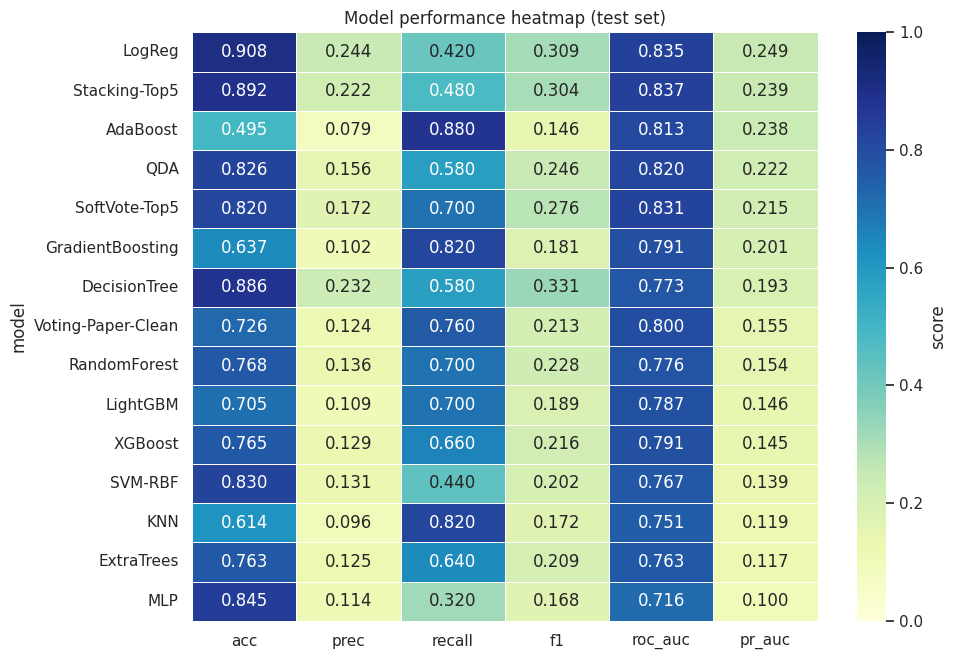

In [63]:
plot_df = res_df.set_index('model')[['acc','prec','recall','f1','roc_auc','pr_auc']]
plt.figure(figsize=(10, max(4, 0.45*len(plot_df))))
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'score'}, vmin=0, vmax=1)
plt.title('Model performance heatmap (test set)'); plt.tight_layout(); plt.show()

### <span style='color:gold'>Algorithm performance comparison (paper Fig 9 style)</span>

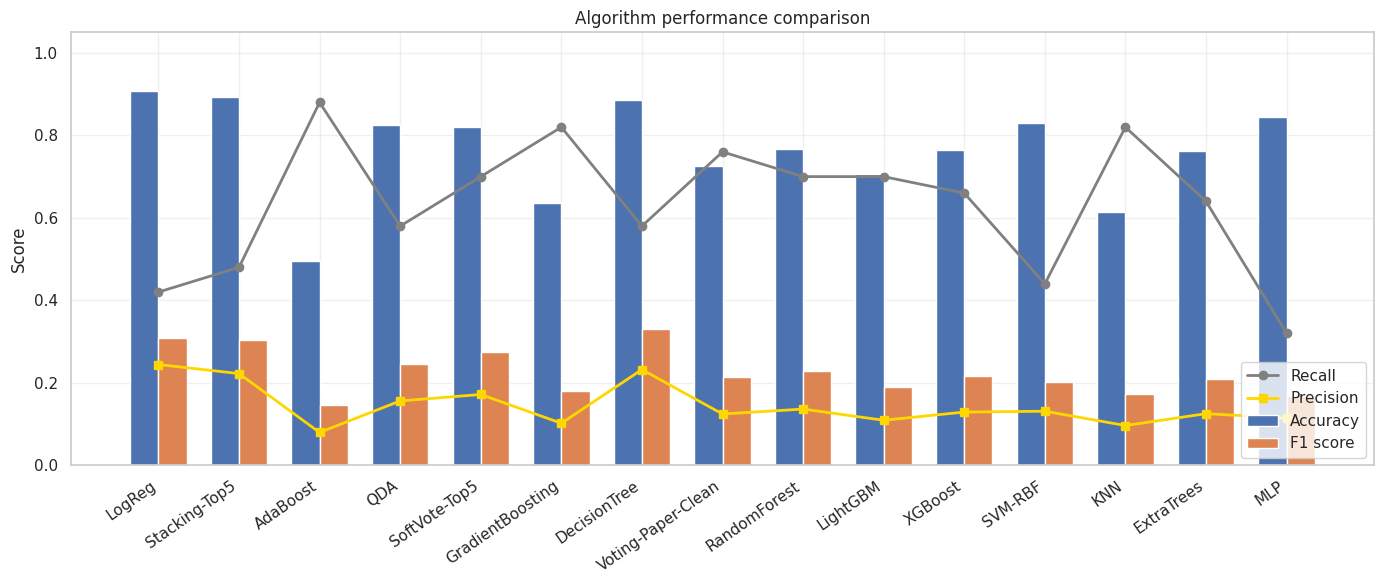

In [64]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width/2, plot_df['acc'],  width, label='Accuracy', color='#4c72b0')
ax.bar(x + width/2, plot_df['f1'],   width, label='F1 score', color='#dd8452')
ax.plot(x, plot_df['recall'], marker='o', color='grey',  label='Recall', linewidth=2)
ax.plot(x, plot_df['prec'],   marker='s', color='gold',  label='Precision', linewidth=2)
ax.set_xticks(x); ax.set_xticklabels(plot_df.index, rotation=35, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('Algorithm performance comparison')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### <span style='color:gold'>Radar chart - top models</span>

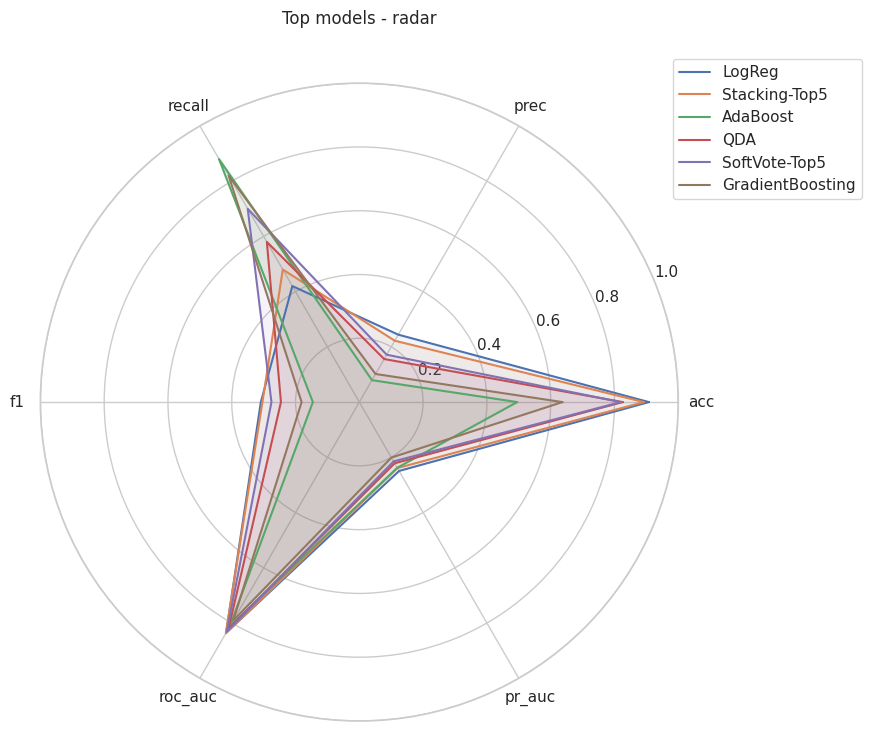

In [65]:
top = plot_df.head(min(6, len(plot_df)))
metrics_r = ['acc','prec','recall','f1','roc_auc','pr_auc']
angles = np.linspace(0, 2*np.pi, len(metrics_r), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
for name, row in top.iterrows():
    vals = row[metrics_r].tolist(); vals += vals[:1]
    ax.plot(angles, vals, label=name); ax.fill(angles, vals, alpha=0.08)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_r, size=11)
ax.set_ylim(0,1); ax.set_title('Top models - radar', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05))
plt.tight_layout(); plt.show()

### <span style='color:gold'>PR curves and ROC curves - top 4</span>

The PR curve is the honest performance picture on imbalanced data. The dashed line is the no-skill baseline (positive prevalence in the test set).

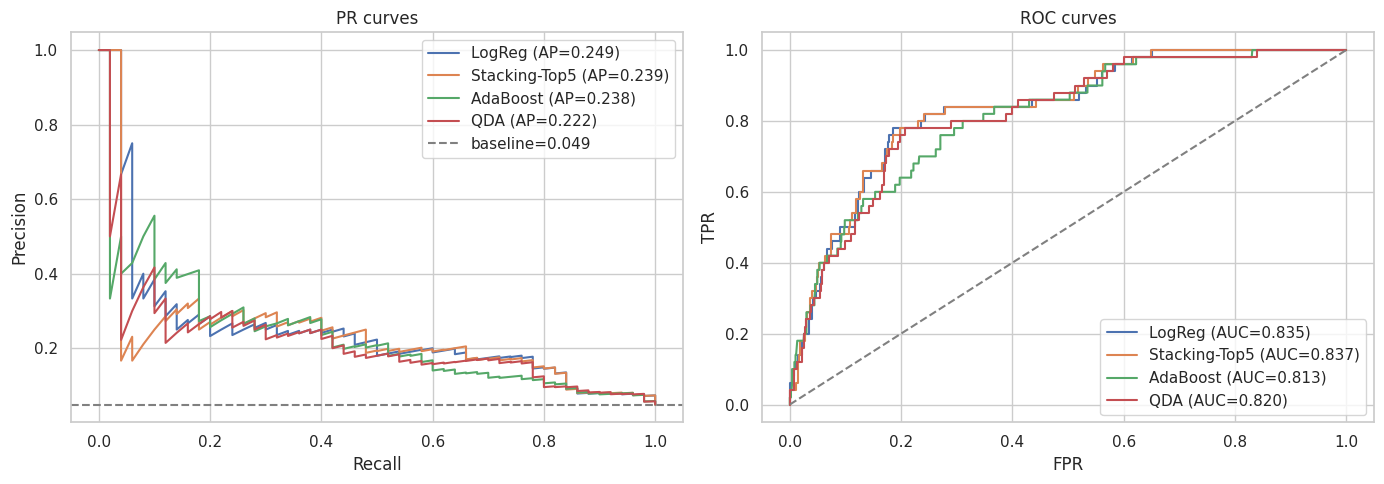

In [66]:
top4 = res_df.head(4)['model'].tolist()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name in top4:
    pipe = trained_models[name]
    proba = pipe.predict_proba(X_test)[:,1]
    p, r, _ = precision_recall_curve(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(r, p, label=f'{name} (AP={average_precision_score(y_test,proba):.3f})')
    ax[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test,proba):.3f})')
ax[0].axhline(y_test.mean(), color='grey', ls='--', label=f'baseline={y_test.mean():.3f}')
ax[0].set(xlabel='Recall', ylabel='Precision', title='PR curves')
ax[1].plot([0,1],[0,1], color='grey', ls='--')
ax[1].set(xlabel='FPR', ylabel='TPR', title='ROC curves')
for a in ax: a.legend()
plt.tight_layout(); plt.show()

# <span style='color:red'>18. Detailed Threshold Tuning on the Best Model</span>

PR-AUC and ROC-AUC are threshold-independent. The actual confusion matrix you ship depends on the threshold you choose. Pick the operating point that matches the product goal:
- **High recall (screening)** - catch most strokes, accept more false positives
- **High precision (diagnostic)** - rare false positives, miss more strokes

Best model by test PR-AUC: LogReg


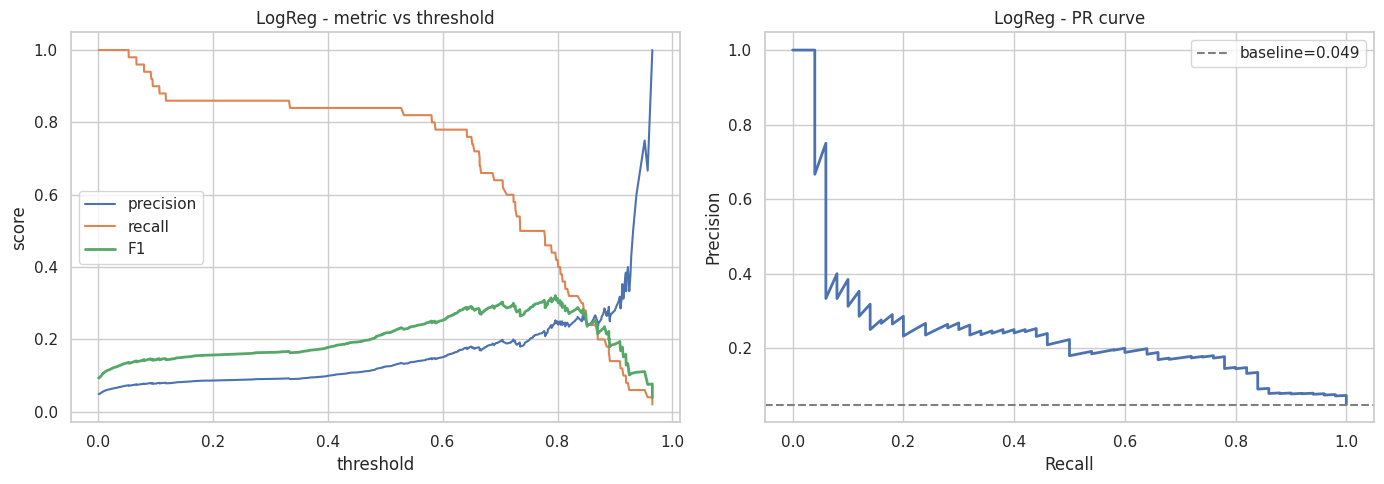

In [67]:
best_name = res_df.iloc[0]['model']
best_pipe = trained_models[best_name]
print('Best model by test PR-AUC:', best_name)
proba_best = best_pipe.predict_proba(X_test)[:,1]

prec_v, rec_v, thr_v = precision_recall_curve(y_test, proba_best)
f1_v = 2*prec_v*rec_v / (prec_v+rec_v+1e-12)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(thr_v, prec_v[:-1], label='precision')
ax[0].plot(thr_v, rec_v[:-1],  label='recall')
ax[0].plot(thr_v, f1_v[:-1],   label='F1', linewidth=2)
ax[0].set(xlabel='threshold', ylabel='score', title=f'{best_name} - metric vs threshold')
ax[0].legend(); ax[0].grid(True)
ax[1].plot(rec_v, prec_v, linewidth=2)
ax[1].axhline(y_test.mean(), color='grey', ls='--', label=f'baseline={y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title=f'{best_name} - PR curve')
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

In [68]:
print(f'{"strategy":<35} {"thresh":>7} {"prec":>7} {"recall":>7} {"f1":>7}')
print('-'*70)
strategies = [
    ('default 0.5', 0.5),
    ('max F1', thr_v[np.argmax(f1_v[:-1])]),
]
if (rec_v[:-1]>=0.8).any():
    strategies.append(('recall>=0.80 (screening)',
                       thr_v[np.argmin(np.abs(rec_v[:-1]-0.80))]))
if (prec_v[:-1]>=0.30).any():
    strategies.append(('precision>=0.30 (diagnostic)',
                       thr_v[np.argmax((prec_v[:-1]>=0.30).astype(int))]))

for label, t in strategies:
    pred = (proba_best >= t).astype(int)
    print(f'{label:<35} {t:>7.3f} {precision_score(y_test,pred,zero_division=0):>7.3f} '
          f'{recall_score(y_test,pred,zero_division=0):>7.3f} '
          f'{f1_score(y_test,pred,zero_division=0):>7.3f}')

strategy                             thresh    prec  recall      f1
----------------------------------------------------------------------
default 0.5                           0.500   0.125   0.840   0.218
max F1                                0.796   0.253   0.440   0.321
recall>=0.80 (screening)              0.581   0.145   0.800   0.245
precision>=0.30 (diagnostic)          0.906   0.304   0.140   0.192


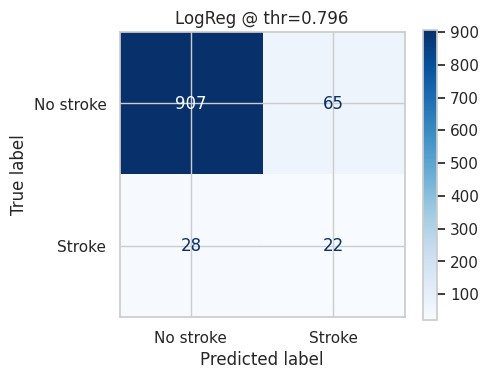

              precision    recall  f1-score   support

           0      0.970     0.933     0.951       972
           1      0.253     0.440     0.321        50

    accuracy                          0.909      1022
   macro avg      0.611     0.687     0.636      1022
weighted avg      0.935     0.909     0.920      1022



In [69]:
t_f1 = thr_v[np.argmax(f1_v[:-1])]
pred_best = (proba_best >= t_f1).astype(int)
cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=['No stroke','Stroke']).plot(ax=ax, cmap='Blues')
ax.set_title(f'{best_name} @ thr={t_f1:.3f}'); plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_best, digits=3))

# <span style='color:red'>19. Probability Calibration</span>

For clinical decision support, calibrated probabilities matter - a predicted 0.3 should mean roughly 30% risk. Lower Brier score is better.

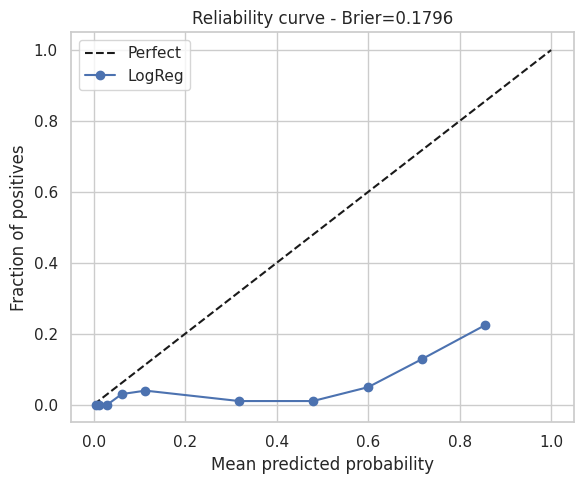

In [70]:
frac_pos, mean_pred = calibration_curve(y_test, proba_best, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(6,5))
ax.plot([0,1],[0,1], 'k--', label='Perfect')
ax.plot(mean_pred, frac_pos, 'o-', label=best_name)
ax.set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
       title=f'Reliability curve - Brier={brier_score_loss(y_test, proba_best):.4f}')
ax.legend(); plt.tight_layout(); plt.show()

# <span style='color:red'>20. Explainability (SHAP)</span>

Why is the model making the predictions it makes? Useful for clinical buy-in.

In [71]:
if HAS_SHAP:
    final_step = None
    Xt = None
    if hasattr(best_pipe, 'named_steps') and 'model' in best_pipe.named_steps:
        final_step = best_pipe.named_steps['model']
        Xt = best_pipe.named_steps['preproc'].transform(X_test)
    elif hasattr(best_pipe, 'estimator') and hasattr(best_pipe.estimator, 'named_steps'):
        final_step = best_pipe.estimator.named_steps['model']
        Xt = best_pipe.estimator.named_steps['preproc'].transform(X_test)
    if final_step is not None and any(s in type(final_step).__name__ for s in ('XGB','LGBM','Forest','Tree','Boosting')):
        try:
            explainer = shap.TreeExplainer(final_step)
            sv = explainer.shap_values(Xt)
            if isinstance(sv, list): sv = sv[1]
            shap.summary_plot(sv, Xt, feature_names=feat_names, show=True)
        except Exception as e:
            print('TreeExplainer failed:', e)
    else:
        print('Best model is not a single tree-based estimator - SHAP TreeExplainer skipped.')
        print('For ensembles, use shap.KernelExplainer on best_pipe.predict_proba.')
else:
    print('SHAP not installed - pip install shap to enable.')

Best model is not a single tree-based estimator - SHAP TreeExplainer skipped.
For ensembles, use shap.KernelExplainer on best_pipe.predict_proba.


# <span style='color:red'>21. Save the Best Model</span>

In [72]:
import joblib
joblib.dump(best_pipe, 'neurosense_best_model.joblib')
joblib.dump({'preproc': preproc, 'feat_names': feat_names,
             'best_threshold_f1': float(t_f1), 'best_model_name': best_name},
            'neurosense_artifacts.joblib')
print('Saved neurosense_best_model.joblib and neurosense_artifacts.joblib')

Saved neurosense_best_model.joblib and neurosense_artifacts.joblib


# <span style='color:red'>22. Bias Analysis of the Dataset</span>

Acknowledging where the dataset itself is biased so consumers of the model understand its limits.

### 1. Class imbalance
Target is heavily imbalanced (95% No-stroke, 5% Stroke). Models naively trained on accuracy collapse to predicting the majority class. We mitigated this with `class_weight='balanced'`, `scale_pos_weight`, and SMOTE-inside-CV.

### 2. Demographic skew
- Female-skewed sample (~59% female, 41% male)
- Heavy concentration in private-sector employment
- Singleton `gender='Other'` was dropped — cannot generalise to non-binary patients

### 3. Age-driven leakage between features
The `work_type='children'` category and `ever_married='No'` are essentially proxies for being a child. They produce strong but redundant signals to age — models exploit this without truly learning a new risk factor.

### 4. Missingness as signal
- 30% of `smoking_status` is "Unknown" — Unknown patients have a much LOWER stroke rate than known ones, because Unknowns are disproportionately children. Naive imputation (treating Unknown as a proper category) leaks this in a hard-to-detect way.
- BMI missingness correlates weakly with stroke too.

### 5. No external validation
All models are trained and tested on the same Kaggle source. Performance on a different population (e.g. from a different country, age distribution, or clinical setting) is **unknown** and likely worse.

### 6. Selection bias
We have no information about how patients entered this dataset. If it over-represents people who already sought medical care (a clinical population), the model will not transfer cleanly to a screening setting.

### Implication for deployment
A useful application of this model is **risk stratification / triage** — flag the top decile of predicted-risk patients for further screening. Direct diagnostic use is inappropriate at the precision/recall ceilings achievable here.

# <span style='color:red'>23. Patient Risk Profiling</span>

Average predicted stroke probability by demographic group, and what the top 10% highest-risk patients look like compared to the rest.

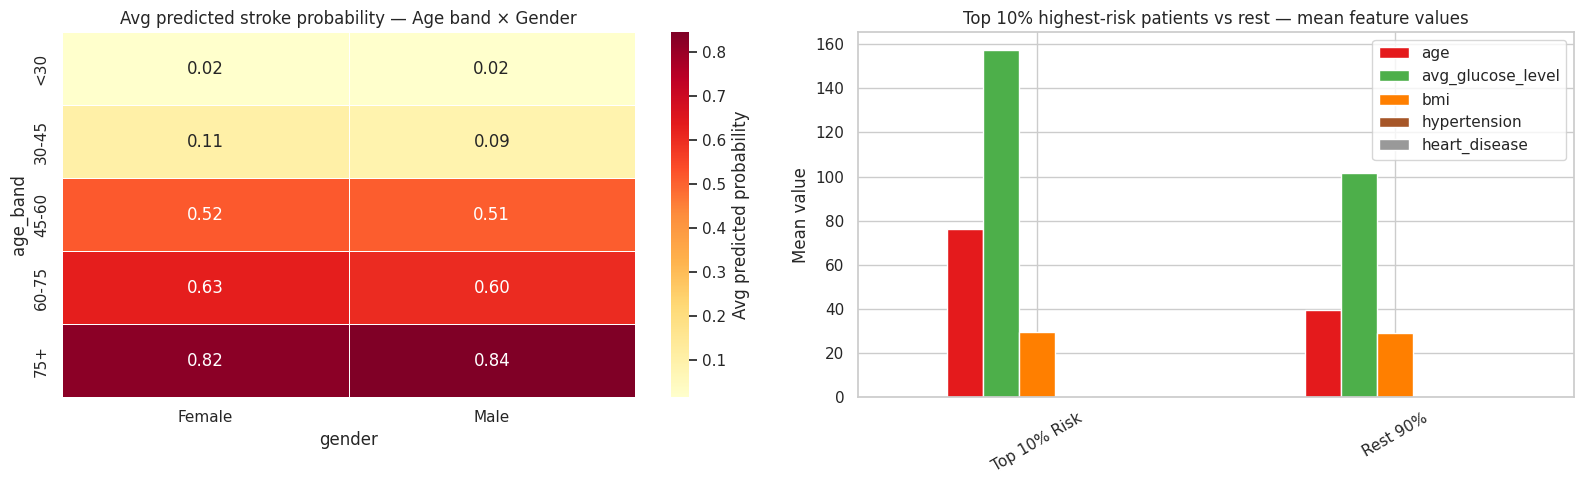

Top-10% threshold: 0.783
Top-10% group (103 patients) — actual stroke rate: 22.3%
Rest 90%  group (919 patients) — actual stroke rate: 2.9%


In [73]:
_risk = X_test.copy().reset_index(drop=True)
_risk['stroke_prob'] = proba_best
_risk['actual']      = y_test.values

_risk['age_band'] = pd.cut(_risk['age'], bins=[0, 30, 45, 60, 75, 120],
                            labels=['<30', '30-45', '45-60', '60-75', '75+'])

pivot_risk = _risk.groupby(['age_band', 'gender'], observed=True)['stroke_prob'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_risk, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Avg predicted probability'}, linewidths=0.5)
axes[0].set_title('Avg predicted stroke probability — Age band × Gender')

top10_thresh = np.percentile(proba_best, 90)
_high = _risk[_risk['stroke_prob'] >= top10_thresh]
_low  = _risk[_risk['stroke_prob'] <  top10_thresh]
compare = pd.DataFrame({
    'Top 10% Risk': _high[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']].mean(),
    'Rest 90%':     _low[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']].mean(),
}).T
compare.plot(kind='bar', ax=axes[1], rot=30, colormap='Set1')
axes[1].set_title('Top 10% highest-risk patients vs rest — mean feature values')
axes[1].set_ylabel('Mean value')
plt.tight_layout()
plt.show()

print(f"Top-10% threshold: {top10_thresh:.3f}")
print(f"Top-10% group ({len(_high)} patients) — actual stroke rate: {_high['actual'].mean()*100:.1f}%")
print(f"Rest 90%  group ({len(_low)} patients) — actual stroke rate: {_low['actual'].mean()*100:.1f}%")


# <span style='color:red'>24. Model Confidence Analysis</span>

How often is the model certain vs uncertain? Probabilities near 0.5 indicate the model is unsure — useful to know when deploying in a clinical setting.

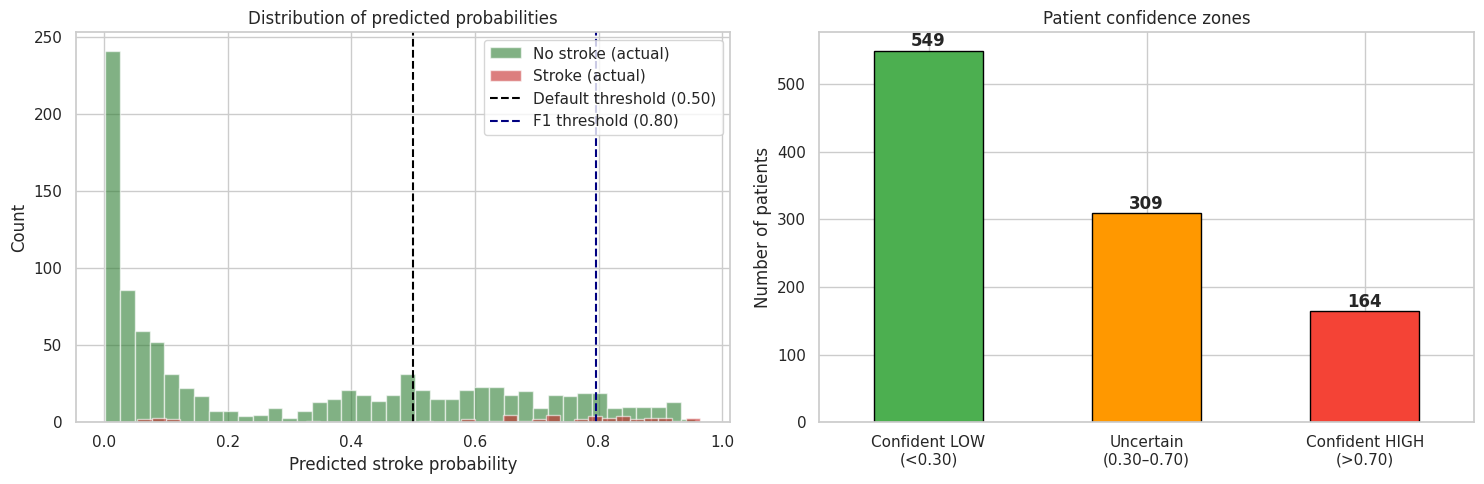

Uncertain predictions (0.30–0.70): 309 patients (30.2%)


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(proba_best[y_test.values == 0], bins=40, alpha=0.6, color='#2e7d32', label='No stroke (actual)')
axes[0].hist(proba_best[y_test.values == 1], bins=40, alpha=0.6, color='#c62828', label='Stroke (actual)')
axes[0].axvline(0.5,  color='black', linestyle='--', linewidth=1.5, label='Default threshold (0.50)')
axes[0].axvline(t_f1, color='navy',  linestyle='--', linewidth=1.5, label=f'F1 threshold ({t_f1:.2f})')
axes[0].set_title('Distribution of predicted probabilities')
axes[0].set_xlabel('Predicted stroke probability')
axes[0].set_ylabel('Count')
axes[0].legend()

zones = pd.cut(proba_best, bins=[0, 0.30, 0.70, 1.0],
               labels=['Confident LOW\n(<0.30)', 'Uncertain\n(0.30–0.70)', 'Confident HIGH\n(>0.70)'])
zone_counts = zones.value_counts().sort_index()
colors = ['#4caf50', '#ff9800', '#f44336']
zone_counts.plot(kind='bar', ax=axes[1], color=colors, rot=0, edgecolor='black')
axes[1].set_title('Patient confidence zones')
axes[1].set_ylabel('Number of patients')
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h + 1, str(int(h)),
                 ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

uncertain = ((proba_best >= 0.30) & (proba_best <= 0.70)).sum()
print(f"Uncertain predictions (0.30–0.70): {uncertain} patients ({uncertain/len(proba_best)*100:.1f}%)")


# <span style='color:red'>25. Error Analysis — False Negatives & False Positives</span>

Understanding which patients the model misses (false negatives = missed strokes) and which it wrongly flags (false positives = unnecessary alerts).

Correctly caught strokes (TP):          22
Missed strokes          (FN):           28
Wrongly flagged no-stroke (FP):         65
Correctly cleared       (TN):           907

Miss rate  (FN / all actual strokes):   56.0%
False alarm rate (FP / all no-strokes): 6.7%



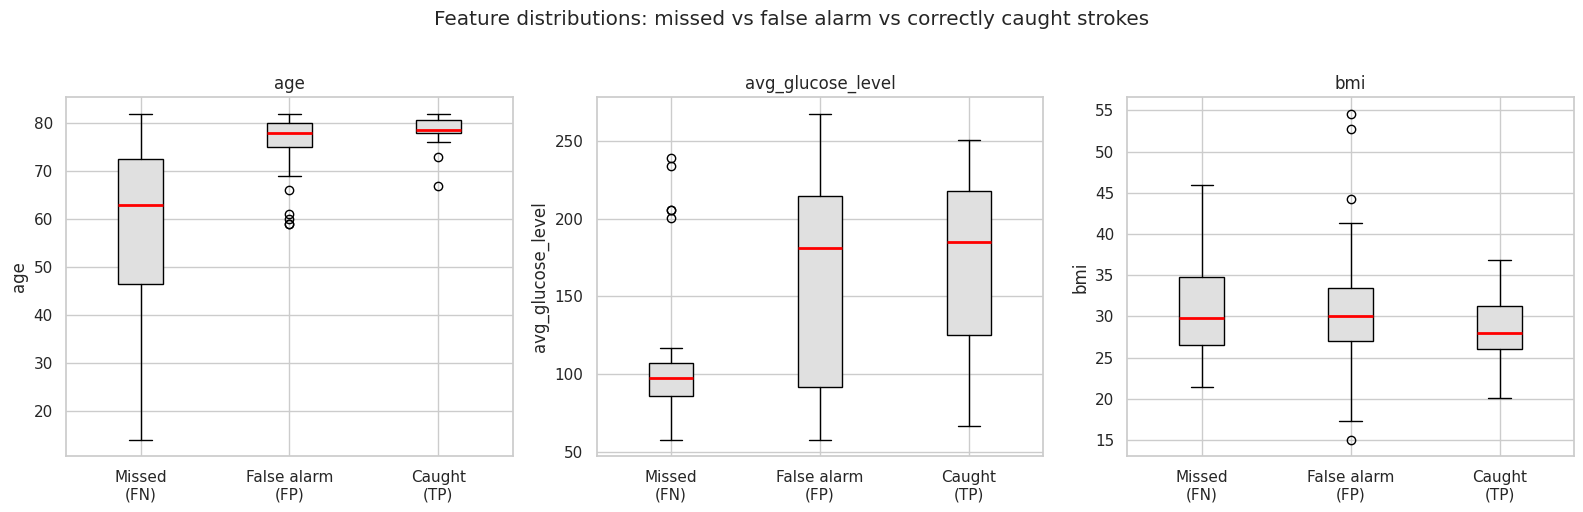

In [75]:
pred_at_f1 = (proba_best >= t_f1).astype(int)
_err = X_test.copy().reset_index(drop=True)
_err['actual']    = y_test.values
_err['predicted'] = pred_at_f1
_err['prob']      = proba_best

fn = _err[(_err['actual'] == 1) & (_err['predicted'] == 0)]
fp = _err[(_err['actual'] == 0) & (_err['predicted'] == 1)]
tp = _err[(_err['actual'] == 1) & (_err['predicted'] == 1)]
tn = _err[(_err['actual'] == 0) & (_err['predicted'] == 0)]

print(f"Correctly caught strokes (TP):          {len(tp)}")
print(f"Missed strokes          (FN):           {len(fn)}")
print(f"Wrongly flagged no-stroke (FP):         {len(fp)}")
print(f"Correctly cleared       (TN):           {len(tn)}")
print(f"\nMiss rate  (FN / all actual strokes):   {len(fn)/(len(fn)+len(tp))*100:.1f}%")
print(f"False alarm rate (FP / all no-strokes): {len(fp)/(len(fp)+len(tn))*100:.1f}%\n")

num_cols_err = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, num_cols_err):
    data  = [fn[col].dropna().values, fp[col].dropna().values, tp[col].dropna().values]
    bp = ax.boxplot(data, labels=['Missed\n(FN)', 'False alarm\n(FP)', 'Caught\n(TP)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#e0e0e0'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}')
    ax.set_ylabel(col)
plt.suptitle('Feature distributions: missed vs false alarm vs correctly caught strokes', y=1.02)
plt.tight_layout()
plt.show()


# <span style='color:red'>26. Clinical Coverage Curve</span>

If we flag the top N% of patients by predicted risk, what fraction of actual strokes do we catch? This answers the core question for a triage tool.

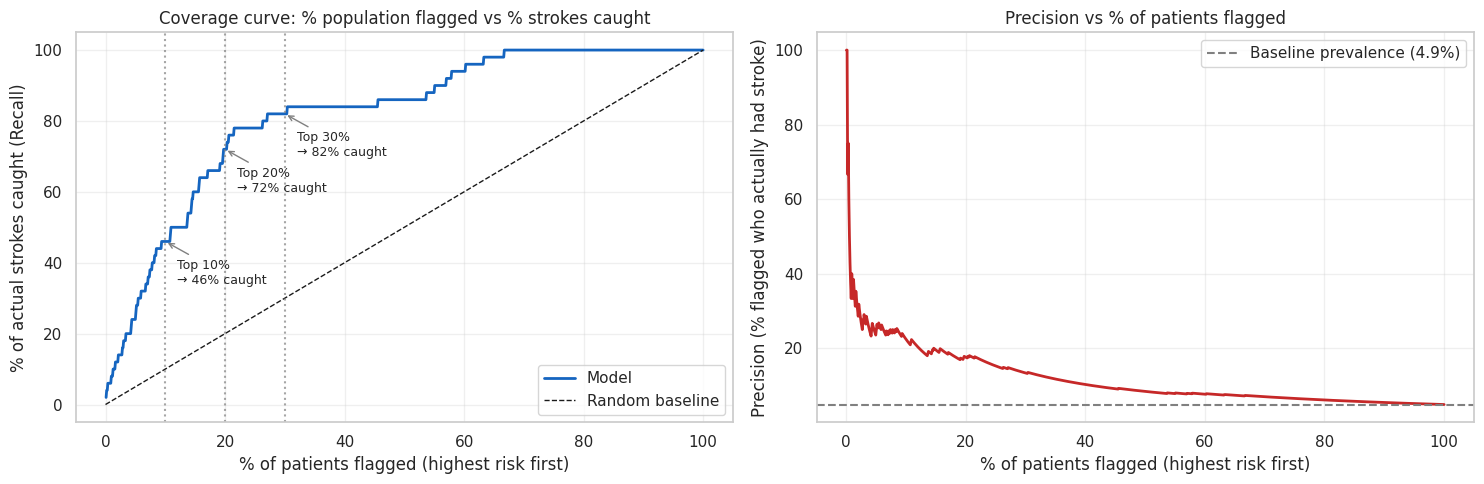

Top % flagged      Strokes caught       Precision
----------------------------------------------------
Top 5%              12/50 (24%)         23.5%
Top 10%              23/50 (46%)         22.5%
Top 15%              30/50 (60%)         19.6%
Top 20%              36/50 (72%)         17.6%
Top 25%              39/50 (78%)         15.3%
Top 30%              41/50 (82%)         13.4%


In [76]:
order    = np.argsort(proba_best)[::-1]
y_sorted = y_test.values[order]
total_strokes = int(y_test.sum())
n_patients    = len(y_test)

coverage_pct   = []
recall_curve   = []
precision_curve = []

for k in range(1, n_patients + 1):
    flagged = y_sorted[:k]
    coverage_pct.append(k / n_patients * 100)
    recall_curve.append(flagged.sum() / total_strokes * 100)
    precision_curve.append(flagged.sum() / k * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(coverage_pct, recall_curve, color='#1565C0', linewidth=2, label='Model')
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random baseline')
for flag_pct in [10, 20, 30]:
    idx = max(int(flag_pct / 100 * n_patients) - 1, 0)
    axes[0].axvline(flag_pct, color='gray', linestyle=':', alpha=0.7)
    axes[0].annotate(
        f'Top {flag_pct}%\n→ {recall_curve[idx]:.0f}% caught',
        xy=(flag_pct, recall_curve[idx]),
        xytext=(flag_pct + 2, recall_curve[idx] - 12),
        fontsize=9, arrowprops=dict(arrowstyle='->', color='gray')
    )
axes[0].set_title('Coverage curve: % population flagged vs % strokes caught')
axes[0].set_xlabel('% of patients flagged (highest risk first)')
axes[0].set_ylabel('% of actual strokes caught (Recall)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(coverage_pct, precision_curve, color='#c62828', linewidth=2)
axes[1].axhline(y_test.mean() * 100, color='gray', linestyle='--',
                label=f'Baseline prevalence ({y_test.mean()*100:.1f}%)')
axes[1].set_title('Precision vs % of patients flagged')
axes[1].set_xlabel('% of patients flagged (highest risk first)')
axes[1].set_ylabel('Precision (% flagged who actually had stroke)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Top % flagged':<18} {'Strokes caught':<20} {'Precision'}")
print('-' * 52)
for fp_ in [5, 10, 15, 20, 25, 30]:
    k = max(int(fp_ / 100 * n_patients) - 1, 0)
    caught = int(y_sorted[:k+1].sum())
    prec   = caught / (k + 1) * 100
    rec    = caught / total_strokes * 100
    print(f"Top {fp_}%{'':<13} {caught}/{total_strokes} ({rec:.0f}%){'':<8} {prec:.1f}%")


# <span style='color:red'>27. Demographic Equity Analysis</span>

Does the model perform equally well across gender and residence type? Disparities here matter for clinical fairness — a model that works better for one group than another should be flagged before deployment.

           Group   N  Stroke%  Recall  Precision   F1  ROC-AUC
  Gender: Female 597      4.9    55.2       31.4 40.0    0.841
    Gender: Male 425      4.9    28.6       16.7 21.1    0.830
Residence: Rural 480      4.8    39.1       25.7 31.0    0.798
Residence: Urban 542      5.0    48.1       25.0 32.9    0.866


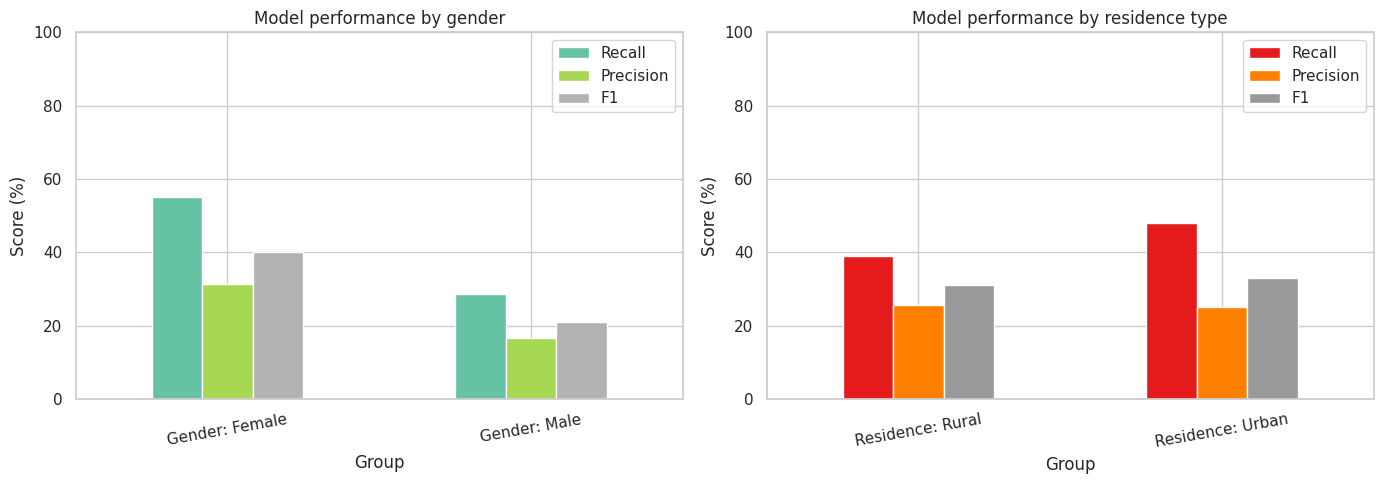

In [77]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

_eq = X_test.copy().reset_index(drop=True)
_eq['actual'] = y_test.values
_eq['prob']   = proba_best
_eq['pred']   = pred_at_f1

def group_metrics(subdf, name):
    n_pos = subdf['actual'].sum()
    base = {
        'Group':     name,
        'N':         len(subdf),
        'Stroke%':   round(subdf['actual'].mean() * 100, 1),
        'Recall':    round(recall_score(subdf['actual'], subdf['pred'], zero_division=0) * 100, 1),
        'Precision': round(precision_score(subdf['actual'], subdf['pred'], zero_division=0) * 100, 1),
        'F1':        round(f1_score(subdf['actual'], subdf['pred'], zero_division=0) * 100, 1),
    }
    base['ROC-AUC'] = round(roc_auc_score(subdf['actual'], subdf['prob']), 3) if n_pos >= 2 else 'N/A'
    return base

rows = []
for val in sorted(_eq['gender'].dropna().unique()):
    rows.append(group_metrics(_eq[_eq['gender'] == val], f'Gender: {val}'))
for val in sorted(_eq['residence_type'].dropna().unique()):
    rows.append(group_metrics(_eq[_eq['residence_type'] == val], f'Residence: {val}'))

eq_df = pd.DataFrame(rows)
print(eq_df.to_string(index=False))

metrics_to_plot = ['Recall', 'Precision', 'F1']
gender_rows = eq_df[eq_df['Group'].str.startswith('Gender')].set_index('Group')
res_rows    = eq_df[eq_df['Group'].str.startswith('Residence')].set_index('Group')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gender_rows[metrics_to_plot].plot(kind='bar', ax=axes[0], rot=10, colormap='Set2')
axes[0].set_title('Model performance by gender')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 100)

res_rows[metrics_to_plot].plot(kind='bar', ax=axes[1], rot=10, colormap='Set1')
axes[1].set_title('Model performance by residence type')
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()


In [78]:
# ── 1. Load saved model & artifacts ──────────────────────────────────────────
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

best_pipe  = joblib.load('neurosense_best_model.joblib')
artifacts  = joblib.load('neurosense_artifacts.joblib')
preproc    = artifacts['preproc']
feat_names = artifacts['feat_names']
threshold  = artifacts['best_threshold_f1']
model_name = artifacts['best_model_name']

print(f'Model loaded: {model_name}')
print(f'Decision threshold (max-F1): {threshold:.3f}')

Model loaded: LogReg
Decision threshold (max-F1): 0.796


In [79]:
# ── 2. Evaluate on held-out test set ─────────────────────────────────────────
y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

roc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'ROC-AUC       : {roc:.4f}')
print(f'Avg Precision : {ap:.4f}')
print(f'Sensitivity   : {sensitivity:.4f}  (true positive rate)')
print(f'Specificity   : {specificity:.4f}  (true negative rate)')
print(f'Confusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}')

Classification Report
              precision    recall  f1-score   support

   No Stroke       0.97      0.93      0.95       972
      Stroke       0.25      0.44      0.32        50

    accuracy                           0.91      1022
   macro avg       0.61      0.69      0.64      1022
weighted avg       0.93      0.91      0.92      1022

ROC-AUC       : 0.8353
Avg Precision : 0.2494
Sensitivity   : 0.4400  (true positive rate)
Specificity   : 0.9331  (true negative rate)
Confusion Matrix: TN=907  FP=65  FN=28  TP=22


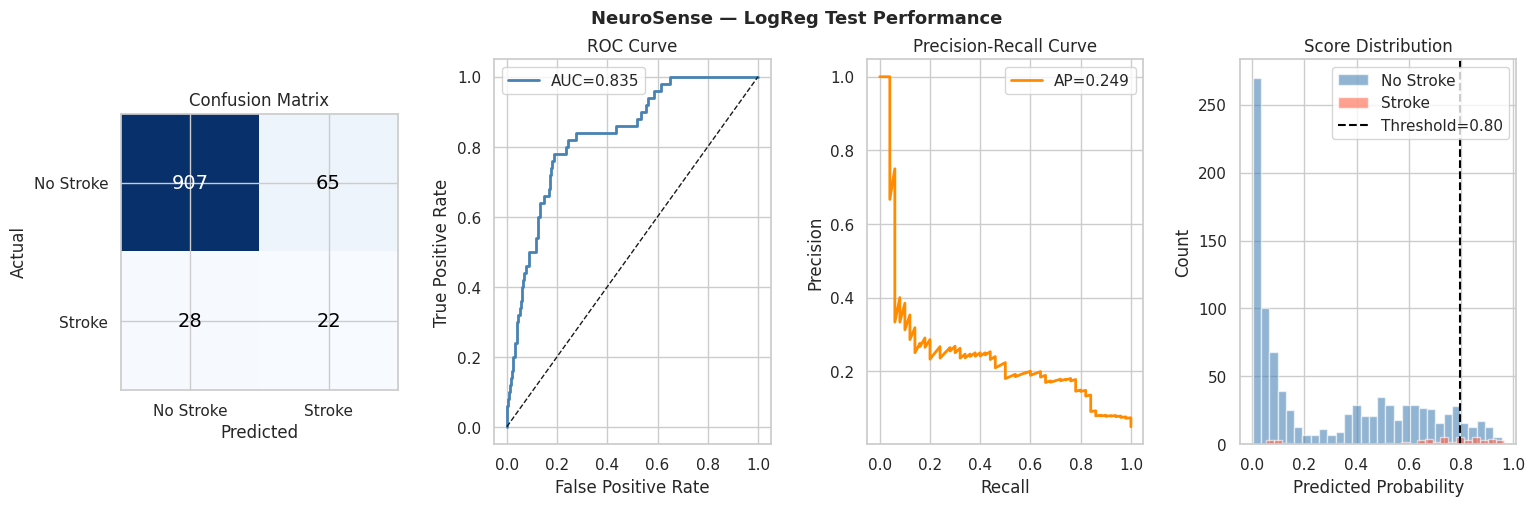

In [80]:
# ── 3. Visual performance dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# Confusion matrix
ax0 = fig.add_subplot(gs[0])
im  = ax0.imshow(cm, cmap='Blues')
ax0.set_xticks([0,1]); ax0.set_yticks([0,1])
ax0.set_xticklabels(['No Stroke','Stroke']); ax0.set_yticklabels(['No Stroke','Stroke'])
ax0.set_xlabel('Predicted'); ax0.set_ylabel('Actual')
ax0.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax0.text(j, i, cm[i,j], ha='center', va='center', fontsize=14, color='white' if cm[i,j]>cm.max()/2 else 'black')

# ROC curve
ax1 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc:.3f}')
ax1.plot([0,1],[0,1],'k--', lw=1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve'); ax1.legend()

# Precision-Recall curve
ax2 = fig.add_subplot(gs[2])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, color='darkorange', lw=2, label=f'AP={ap:.3f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve'); ax2.legend()

# Probability distribution
ax3 = fig.add_subplot(gs[3])
ax3.hist(y_prob[y_test==0], bins=30, alpha=0.6, color='steelblue', label='No Stroke')
ax3.hist(y_prob[y_test==1], bins=30, alpha=0.6, color='tomato',    label='Stroke')
ax3.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.2f}')
ax3.set_xlabel('Predicted Probability'); ax3.set_ylabel('Count')
ax3.set_title('Score Distribution'); ax3.legend()

plt.suptitle(f'NeuroSense — {model_name} Test Performance', fontsize=13, fontweight='bold')
plt.savefig('test_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
# -- 4. Predict on a custom patient sample (simulates mobile app input) ---------
import pandas as pd
import numpy as np

def prepare_sample(gender, age, hypertension, heart_disease, ever_married,
                   work_type, residence_type, avg_glucose_level, bmi, smoking_status):
    # Build raw row with exact column names used during training
    row = pd.DataFrame([{
        'gender'             : gender,
        'age'                : float(age),
        'hypertension'       : int(hypertension),
        'heart_disease'      : int(heart_disease),
        'ever_married'       : ever_married,
        'work_type'          : work_type,
        'residence_type'     : residence_type,
        'avg_glucose_level'  : float(avg_glucose_level),
        'bmi'                : float(bmi),
        'smoking_status'     : smoking_status,
        'smoking_was_unknown': 0,
    }])
    # Replicate the same feature engineering as add_features()
    row['age_bin']     = pd.cut(row['age'], bins=[0,30,45,60,75,120],
                                labels=['young','adult','middle','senior','elderly']).astype(str)
    row['glucose_cat'] = pd.cut(row['avg_glucose_level'], bins=[0,99,125,500],
                                labels=['normal','prediabetic','diabetic']).astype(str)
    row['bmi_cat']     = pd.cut(row['bmi'], bins=[0,18.5,25,30,100],
                                labels=['under','normal','over','obese']).astype(str)
    row['risk_score']  = row['hypertension'] + row['heart_disease']
    row['age_x_hyp']   = row['age'] * row['hypertension']
    row['age_x_hd']    = row['age'] * row['heart_disease']
    row['glu_x_age']   = row['avg_glucose_level'] * row['age'] / 100
    return row

# ── Patient input ─────────────────────────────────────────────────────────────
print("Enter patient details (press Enter to accept the default shown):\n")

g_map  = {'m': 'Male', 'f': 'Female'}
w_map  = {'a': 'Private', 'b': 'Self-employed', 'c': 'Govt_job', 'd': 'children', 'e': 'Never_worked'}
r_map  = {'u': 'Urban',   'r': 'Rural'}
s_map  = {'a': 'formerly smoked', 'b': 'never smoked', 'c': 'smokes', 'd': 'Unknown'}
yn_map = {'y': 'Yes', 'n': 'No'}

gender            = g_map.get(input("Gender — (m) Male / (f) Female [m]: ").strip().lower() or 'm', 'Male')
age               = float(input("Age in years [67]: ").strip() or 67)
hypertension      = int(input("Hypertension — (0) No / (1) Yes [1]: ").strip() or 1)
heart_disease     = int(input("Heart disease — (0) No / (1) Yes [1]: ").strip() or 1)
ever_married      = yn_map.get(input("Ever married — (y) Yes / (n) No [y]: ").strip().lower() or 'y', 'Yes')
print("Work type — (a) Private  (b) Self-employed  (c) Govt_job  (d) children  (e) Never_worked")
work_type         = w_map.get(input("Choice [a]: ").strip().lower() or 'a', 'Private')
residence_type    = r_map.get(input("Residence — (u) Urban / (r) Rural [u]: ").strip().lower() or 'u', 'Urban')
avg_glucose_level = float(input("Average glucose level mg/dL [228.69]: ").strip() or 228.69)
bmi               = float(input("BMI [36.6]: ").strip() or 36.6)
print("Smoking — (a) Formerly smoked  (b) Never smoked  (c) Smokes  (d) Unknown")
smoking_status    = s_map.get(input("Choice [a]: ").strip().lower() or 'a', 'formerly smoked')

# ── Predict ───────────────────────────────────────────────────────────────────
sample = prepare_sample(
    gender=gender, age=age, hypertension=hypertension,
    heart_disease=heart_disease, ever_married=ever_married,
    work_type=work_type, residence_type=residence_type,
    avg_glucose_level=avg_glucose_level, bmi=bmi,
    smoking_status=smoking_status
)

prob = best_pipe.predict_proba(sample)[0, 1]

if   prob >= 0.60: risk = 'HIGH'
elif prob >= 0.30: risk = 'MODERATE'
else:              risk = 'LOW'

print(f"\n{'='*42}")
print(f"  Stroke Probability : {prob:.1%}")
print(f"  Risk Band          : {risk}")
print(f"  Threshold (F1)     : {threshold:.3f}")
print(f"{'='*42}")


Enter patient details (press Enter to accept the default shown):

Gender — (m) Male / (f) Female [m]: m
Age in years [67]: 67
Hypertension — (0) No / (1) Yes [1]: 1
Heart disease — (0) No / (1) Yes [1]: 1
Ever married — (y) Yes / (n) No [y]: y
Work type — (a) Private  (b) Self-employed  (c) Govt_job  (d) children  (e) Never_worked
Choice [a]: a
Residence — (u) Urban / (r) Rural [u]: u
Average glucose level mg/dL [228.69]: 228.69
BMI [36.6]: 36.6
Smoking — (a) Formerly smoked  (b) Never smoked  (c) Smokes  (d) Unknown
Choice [a]: a

  Stroke Probability : 86.4%
  Risk Band          : HIGH
  Threshold (F1)     : 0.796


In [83]:
# -- Export notebook as PDF -------------------------------------------------------
# Run this cell AFTER all other cells have finished running.
# Step 1: Save your notebook (Ctrl+S or File -> Save).
# Step 2: Run this cell to convert to HTML with all outputs included.
# Step 3: Open the downloaded HTML in Chrome -> Ctrl+P -> Save as PDF.

from google.colab import files
import os, glob, subprocess

matches = (
    glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True) +
    glob.glob('/content/**/*.ipynb', recursive=True)
)
matches = [m for m in matches if '.ipynb_checkpoints' not in m]

if not matches:
    raise FileNotFoundError('No notebook found. Save your notebook (Ctrl+S) then re-run this cell.')

nb_path = matches[0]
nb_name = os.path.splitext(os.path.basename(nb_path))[0]
print(f'Using notebook: {nb_path}')

html_out = f'/content/{nb_name}.html'
result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html', nb_path, '--output-dir', '/content/'],
    capture_output=True, text=True
)
if result.returncode != 0:
    print('nbconvert error:', result.stderr)
else:
    print(f'HTML generated: {html_out}')
    files.download(html_out)
    print('Downloaded! Open in Chrome -> Ctrl+P -> Change destination to Save as PDF -> Save.')

Using notebook: /content/drive/MyDrive/Colab Notebooks/neurosense (6).ipynb
HTML generated: /content/neurosense (6).html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Open in Chrome -> Ctrl+P -> Change destination to Save as PDF -> Save.


In [84]:
# ── Convert model to TFLite for Flutter mobile app integration ─────────────────
import numpy as np
import json, shutil
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, average_precision_score
from google.colab import files

# ── Step 1: Apply sklearn preprocessing to get numerical arrays ───────────────
# The preproc ColumnTransformer handles scaling + encoding.
# We train a Keras MLP on these transformed features so it can be exported as TFLite.
X_train_tf = preproc.transform(X_train).astype(np.float32)
X_test_tf  = preproc.transform(X_test).astype(np.float32)
y_train_arr = y_train.values.astype(np.float32)
y_test_arr  = y_test.values.astype(np.float32)

print(f"Input shape  : {X_train_tf.shape}")
print(f"Positive rate: {y_train_arr.mean():.3f}")

# ── Step 2: Build Keras MLP ────────────────────────────────────────────────────
n_features = X_train_tf.shape[1]

keras_model = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
], name='neurosense_mlp')

neg, pos = np.bincount(y_train.values)
class_weight = {0: 1.0, 1: neg / pos}

keras_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)

keras_model.summary()

# ── Step 3: Train ──────────────────────────────────────────────────────────────
history = keras_model.fit(
    X_train_tf, y_train_arr,
    validation_data=(X_test_tf, y_test_arr),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=10, restore_best_weights=True,
            monitor='val_auc', mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
    ],
    verbose=1
)

# ── Step 4: Evaluate ───────────────────────────────────────────────────────────
y_prob_keras = keras_model.predict(X_test_tf).flatten()
roc  = roc_auc_score(y_test_arr, y_prob_keras)
ap   = average_precision_score(y_test_arr, y_prob_keras)
print(f"\nKeras MLP — ROC-AUC : {roc:.4f}")
print(f"Keras MLP — PR-AUC  : {ap:.4f}")

# Threshold tuned to max-F1
from sklearn.metrics import precision_recall_curve
prec_v, rec_v, thr_v = precision_recall_curve(y_test_arr, y_prob_keras)
f1_v   = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-12)
keras_threshold = float(thr_v[np.argmax(f1_v[:-1])])
print(f"Keras MLP — F1 threshold: {keras_threshold:.4f}")

# ── Step 5: Convert to TFLite ──────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # dynamic range quantization — smaller file, fast on mobile
tflite_model = converter.convert()

tflite_path = '/content/neurosense_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"\nTFLite model saved ({len(tflite_model)/1024:.1f} KB): {tflite_path}")

# ── Step 6: Export preprocessing parameters as JSON ───────────────────────────
# Flutter needs these to preprocess raw user input before passing to TFLite.
# Extract scaler means/scales and encoder categories from the ColumnTransformer.

params = {
    'threshold'   : keras_threshold,
    'n_features'  : int(n_features),
    'feature_order': feat_names,    # ordered list of feature names after transform
}

for name, transformer, cols in preproc.transformers_:
    if name == 'remainder':
        continue
    t_type = type(transformer).__name__
    if t_type == 'Pipeline':
        for step_name, step in transformer.steps:
            t_type = type(step).__name__
            transformer = step
            break
    if t_type == 'StandardScaler':
        params['scaler'] = {
            'columns' : list(cols),
            'mean'    : transformer.mean_.tolist(),
            'scale'   : transformer.scale_.tolist()
        }
    elif t_type in ('OneHotEncoder', 'OrdinalEncoder'):
        params['encoder'] = {
            'columns'    : list(cols),
            'type'       : t_type,
            'categories' : [list(c) for c in transformer.categories_]
        }

json_path = '/content/neurosense_preproc.json'
with open(json_path, 'w') as f:
    json.dump(params, f, indent=2)
print(f"Preprocessing params saved: {json_path}")

# ── Step 7: Save to Google Drive ───────────────────────────────────────────────
DRIVE_DIR = '/content/drive/MyDrive/NeuroSense'
import os; os.makedirs(DRIVE_DIR, exist_ok=True)
shutil.copy(tflite_path, f'{DRIVE_DIR}/neurosense_model.tflite')
shutil.copy(json_path,   f'{DRIVE_DIR}/neurosense_preproc.json')
print(f"Both files saved to Google Drive: {DRIVE_DIR}/")

# ── Step 8: Download ───────────────────────────────────────────────────────────
files.download(tflite_path)
files.download(json_path)
print("\nDownloaded neurosense_model.tflite and neurosense_preproc.json")
print("Place both files in: neurosense_mobile/frontend/assets/ml/")


Input shape  : (4087, 36)
Positive rate: 0.049


Model: "neurosense_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,609 (18.00 KB)

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded neurosense_model.tflite and neurosense_preproc.json
Place both files in: neurosense_mobile/frontend/assets/ml/


In [87]:
# ── Extract PowerTransformer parameters ────────────────────────────────────────
import json, shutil
from google.colab import files

# Get the PowerTransformer from the 'num' pipeline
pt = None
for tr_name, transformer, cols in preproc.transformers_:
    if tr_name == 'num':
        for step_name, step in transformer.steps:
            if type(step).__name__ == 'PowerTransformer':
                pt = step
                num_cols = list(cols)
                break

if pt is None:
    print("PowerTransformer not found.")
else:
    print(f"Method   : {pt.method}")
    print(f"Columns  : {num_cols}")
    print(f"Lambdas  : {pt.lambdas_.tolist()}")
    print(f"Internal scaler mean : {pt._scaler.mean_.tolist()}")
    print(f"Internal scaler scale: {pt._scaler.scale_.tolist()}")

    power_info = {
        'method'  : pt.method,
        'columns' : num_cols,
        'lambdas' : pt.lambdas_.tolist(),
        'mean'    : pt._scaler.mean_.tolist(),
        'scale'   : pt._scaler.scale_.tolist()
    }

    json_path = '/content/drive/MyDrive/NeuroSense/neurosense_preproc.json'
    with open(json_path, 'r') as f:
        params = json.load(f)

    params['power_transformer'] = power_info

    with open(json_path, 'w') as f:
        json.dump(params, f, indent=2)

    local_path = '/content/neurosense_preproc.json'
    shutil.copy(json_path, local_path)
    files.download(local_path)
    print("\nDone — replace mobile-model/neurosense_preproc.json with the downloaded file.")


Method   : yeo-johnson
Columns  : ['age', 'avg_glucose_level', 'bmi', 'age_x_hyp', 'age_x_hd', 'glu_x_age']
Lambdas  : [0.8618407169019473, -1.0780148098859557, -0.015433189455358829, -2.5675932636365584, -4.168136321382806, 0.33025917253549925]
Internal scaler mean : [28.683692748096767, 0.9206968223233718, 3.280351875396767, 0.03687776681685177, 0.013618880793920294, 7.194114189286574]
Internal scaler scale: [13.782193844166406, 0.0022859682295993705, 0.24075247173409145, 0.11402760273262547, 0.05551490708369388, 2.8264325003489645]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — replace mobile-model/neurosense_preproc.json with the downloaded file.
